# USEPA 2018-2019 Feature Engineering
In this notebook, we will be addressing a few paths that could be taken for model building. **These choices will heavily affect model outcome, so a log of tested scenarios using different data is presented in the 'training' folder.**

Emma Reilly Oare

In [46]:
# Read in libs
import os 
import warnings 
import pandas as pd  
import numpy as np
import scipy.stats as stats 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, PowerTransformer, QuantileTransformer

# Suppress warnings
warnings.filterwarnings("ignore")

## Step 1. Import Dataset

In [2]:
# Define base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

In [6]:
#  Read in dataset
epa_path = os.path.join(BASE_DIR, "data", "processed", "national", "usepa_post_eda_trim.xlsx")
epa_1819 = pd.read_excel(epa_path).drop(columns = 'Unnamed: 0')

In [7]:
# Display dataframe
epa_1819

,Site ID,Unique ID,LAT_DD83,LON_DD83,Collection Date,Mean streambed embeddedness (%),Bankfull Shear Velocity (m/s),Mean high values of soil bulk density,Mean watershed elevation,% of watershed areas classified as evergreen forest land cover,Mean of all hydraulic conductivity of surface or near surface geology values within watershed,% crop land,% deciduous forest,% hay,Mean imperviousness of anthropogenic surfaces within watershed,Horton overland flow,Estimated watershed annual runoff,Mean Composite Topographic Index (CTI)[Wetness Index],DIVISION
0,NRS18_OK_10062,2014737,35.545389,-99.722705,2018-06-20,100.000000,0.136881,1.651461,713.215273,0.000000,4.391568,2.148320,0.000000,0.017187,0.384291,23.797886,15.044169,783.256509,INTERIOR PLAINS
1,NRS18_OK_10431,2012488,36.902168,-95.164255,2018-06-25,58.272727,0.099543,1.566628,264.820567,0.129099,0.190633,2.711077,15.375678,75.961787,0.350762,14.686742,316.444229,854.012910,INTERIOR PLAINS
2,NRS18_OK_10025,2012489,33.929449,-96.070242,2018-07-02,96.363636,0.243826,1.619647,242.522807,0.404160,1.053346,0.190471,25.591785,21.974691,1.040467,11.814687,258.166777,855.466717,ATLANTIC PLAIN
3,NRS18_WI_10091,2012490,42.536868,-89.395560,2018-07-02,53.418182,0.205462,1.541781,270.240009,0.000000,0.057551,82.225514,2.277356,11.034994,0.820033,5.816515,268.000000,781.569154,INTERIOR PLAINS
4,NRS18_WI_10006,2012491,45.496257,-87.982493,2018-07-12,83.222222,0.065650,1.477531,361.518160,2.329856,0.399779,0.334325,43.025784,1.453402,0.372214,0.151444,282.252458,882.425172,LAURENTIAN UPLAND
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1205,NRS18_ND_10676,2014707,47.115919,-103.577316,2019-09-24,54.909091,0.076556,1.489619,985.968915,2.022914,11.509658,7.548997,0.637791,2.321166,0.195841,12.643175,20.182804,817.928745,INTERIOR PLAINS
1206,NRS18_PA_10009,2014708,41.922584,-77.129228,2019-09-25,38.781818,0.118971,1.512844,535.954972,1.362292,0.146364,0.539690,44.290340,25.256653,1.080702,2.303129,384.760318,745.453162,APPALACHIAN HIGHLANDS
1207,NRS18_SD_10005,2014714,43.070132,-98.800398,2019-09-25,61.083333,0.164587,1.318988,560.868431,0.009684,6.580424,19.472869,5.874948,0.971626,0.281433,45.833549,18.789761,749.269473,INTERIOR PLAINS
1208,NRS18_NC_10897,2014715,35.996645,-80.336835,2019-09-24,100.000000,0.088388,1.496762,266.633024,2.364878,0.161872,0.877015,21.166792,7.810429,17.165070,6.575107,487.483833,756.213330,APPALACHIAN HIGHLANDS


## Step 2. Address imbalanced target
In the prior EDA notebook, we noticed that the target is heavily left-skewed. When visualizing this information on a map, we can see a *clear* area of the U.S. with high embeddedness.
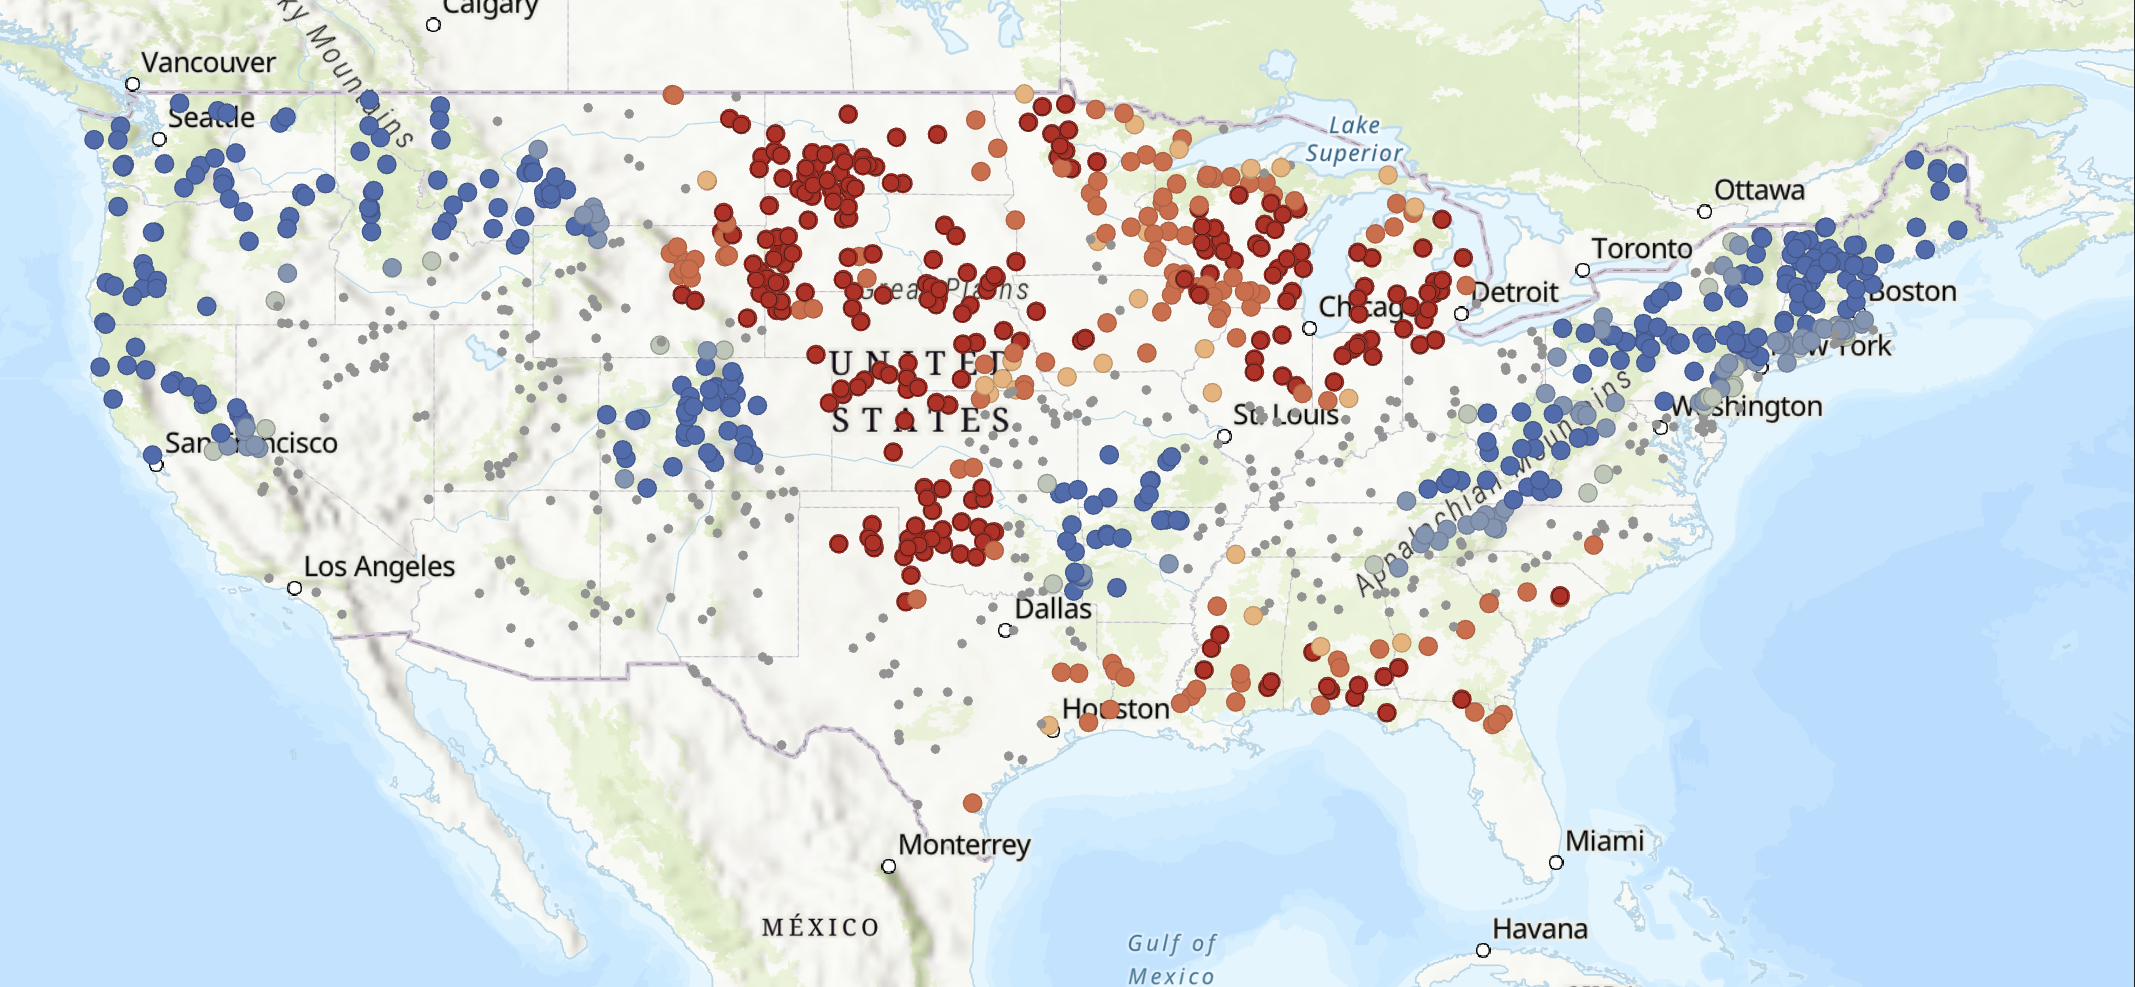
This is not due to any specific impairment, rather likely due to very low slopes and high sediment inputs in these regions. Therefore, we can assume that these areas will already experience near 100% embeddedness. Given that information, we could remove data points above a certain level of embeddedness to balance the dataset appropriately for predictions.

In [8]:
# Identify how many data points are above 95% embeddedness
(epa_1819['Mean streambed embeddedness (%)'] >= 95).value_counts()

Mean streambed embeddedness (%)
False    990
True     220
Name: count, dtype: int64

There's 220 data points above 95%, so we will apply **undersampling techniques.**

In [9]:
# Define threshold
threshold = 95

# Split the data
df_below = epa_1819[epa_1819['Mean streambed embeddedness (%)'] <= threshold]
df_above = epa_1819[epa_1819['Mean streambed embeddedness (%)'] > threshold]

# Determine new sample size
# Define 12 bins (equally spaced)
epa_1819['bin'] = pd.cut(epa_1819['Mean streambed embeddedness (%)'], bins=12)

# Compute bin counts
bin_counts = epa_1819['bin'].value_counts().sort_index()

# Exclude the last bin (>95) and compute the average count
avg_bin_size = int(bin_counts.iloc[:-1].mean())

In [10]:
# Random undersampling
df_above_sampled = df_above.sample(n=min(avg_bin_size, len(df_above)), random_state=42)

In [11]:
# Combine both subsets
epa_1819_trim1 = pd.concat([df_below, df_above_sampled]).sample(frac=1, random_state=42)  # Shuffle

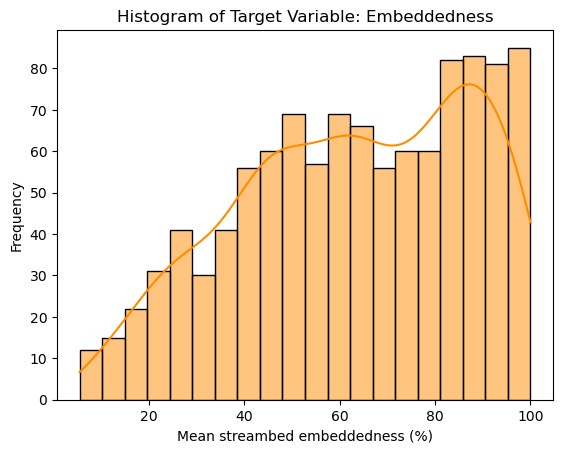

In [13]:
# Historam of target --> Mean streambed embeddedness (%)
sns.histplot(data = epa_1819_trim1,
             x = 'Mean streambed embeddedness (%)',
             bins = 20,
             color = 'darkorange',
             kde = True)

plt.title("Histogram of Target Variable: Embeddedness")
plt.xlabel('Mean streambed embeddedness (%)')
plt.ylabel('Frequency')

# Show figure
plt.show()

**Let's do one more chop of our new majority class, anything above 80.**

In [14]:
# Define threshold
threshold = 80

# Split the data
df_below = epa_1819_trim1[epa_1819_trim1['Mean streambed embeddedness (%)'] <= threshold]
df_above = epa_1819_trim1[epa_1819_trim1['Mean streambed embeddedness (%)'] > threshold]

# Determine new sample size
# Define 4 bins (equally spaced)
epa_1819_trim1['bin'] = pd.cut(epa_1819_trim1['Mean streambed embeddedness (%)'], bins=4)

# Compute bin counts
bin_counts = epa_1819_trim1['bin'].value_counts().sort_index()

# Exclude the last bin (>95) and compute the average count
avg_bin_size = int(bin_counts.iloc[:-1].mean())

In [15]:
# Random undersampling
df_above_sampled = df_above.sample(n=min(avg_bin_size, len(df_above)), random_state=42)

In [16]:
# Combine both subsets
epa_1819_trim2 = pd.concat([df_below, df_above_sampled]).sample(frac=1, random_state=42)  # Shuffle

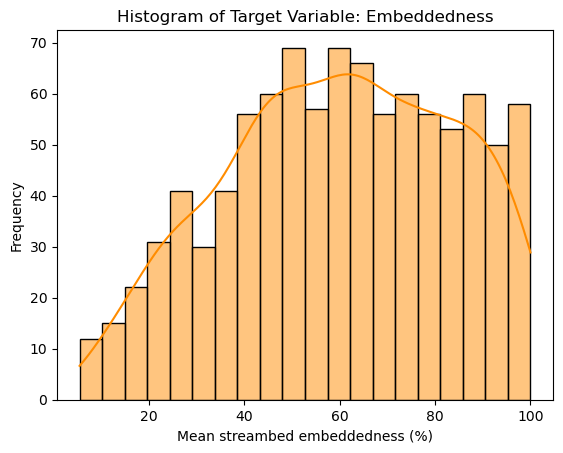

In [19]:
# Historam of target --> Mean streambed embeddedness (%)
sns.histplot(data = epa_1819_trim2,
             x = 'Mean streambed embeddedness (%)',
             bins = 20,
             color = 'darkorange',
             kde = True)

plt.title("Histogram of Target Variable: Embeddedness")
plt.xlabel('Mean streambed embeddedness (%)')
plt.ylabel('Frequency')

# Show figure
plt.show()

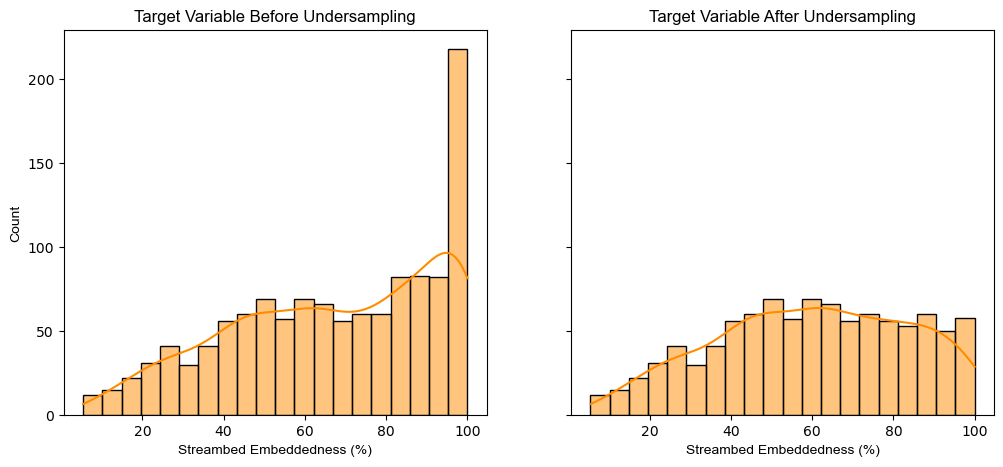

In [20]:
# Create final visualization for paper

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# First Histogram (Before Undersampling)
sns.histplot(epa_1819['Mean streambed embeddedness (%)'], 
             bins=20, kde=True, ax=axes[0], color = 'darkorange', alpha = 0.5)
axes[0].set_title("Target Variable Before Undersampling", fontname = 'Arial')
axes[0].set_xlabel("Streambed Embeddedness (%)", fontname = 'Arial')
axes[0].set_ylabel("Count", fontname = 'Arial')

# Second Histogram (After Undersampling)
sns.histplot(epa_1819_trim2['Mean streambed embeddedness (%)'], 
             bins=20, kde=True, ax=axes[1], color = 'darkorange', alpha = 0.5)
axes[1].set_title("Target Variable After Undersampling", fontname = 'Arial')
axes[1].set_xlabel("Streambed Embeddedness (%)", fontname = 'Arial')
axes[1].set_ylabel("Count", fontname = 'Arial')

# Save plot
target_hist_path = os.path.join(BASE_DIR, 'usepa_nrsa', 'eda', 'figures', 'epa_hist_undersample.png')
plt.savefig(target_hist_path, dpi = 300)

# Show plot
plt.show()

In [21]:
# Double-check final counts
epa_1819_trim2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 230 to 1165
Data columns (total 19 columns):
 #   Column                                                                                         Non-Null Count  Dtype         
---  ------                                                                                         --------------  -----         
 0   Site ID                                                                                        962 non-null    object        
 1   Unique ID                                                                                      962 non-null    int64         
 2   LAT_DD83                                                                                       962 non-null    float64       
 3   LON_DD83                                                                                       962 non-null    float64       
 4   Collection Date                                                                                962 non-nul

In [22]:
# For the sake of usabilty
epa_1819 = epa_1819_trim2.copy()

Next, we apply transformations.

## Step 3. Feature & Target Engineering

We will explore transforming the feature sets and target column to more closely follow a Gaussian distribution. We will use visual and statistical methods to select the best transformation tested. We will test:
- log
- square root
- power
- box-cox
- reciprocal
- Yeo-Johnson Power Transformation
- Normal Quantile Transformation

We will go through each numerical column individually below. First, we will focus on our target feature.

### Step 3a. Visualize transformations

In [23]:
# Define function for applying transformations
def apply_transformation(data, transform):
    if transform == 'log':
        return np.log(data + 1)
    elif transform == 'sqrt':
        return np.sqrt(data)
    elif transform == 'cbrt':
        return np.power(data, 1/3)
    elif transform == 'boxcox':
        if (data > 0).all():
            return stats.boxcox(data)[0]
        else:
            return None
    elif transform == 'reciprocal':
        return 1 / (data + 1)
    elif transform == 'yeo_johnson':
        pt = PowerTransformer(method='yeo-johnson')
        return pt.fit_transform(data.values.reshape(-1, 1)).flatten()
    elif transform == 'quantile_normal':
        qt = QuantileTransformer(output_distribution='normal')
        return qt.fit_transform(data.values.reshape(-1, 1)).flatten()
    else:
        return data

# Define function for evaluating normality based on statistical measures (Shapiro and Anderson)
def evaluate_normality(data):
    shapiro_stat, shapiro_p_value = stats.shapiro(data)
    ad_stat, ad_critical_values, ad_significance_level = stats.anderson(data, dist='norm')
    return {
        'shapiro_stat': shapiro_stat,
        'shapiro_p_value': shapiro_p_value,
        'ad_stat': ad_stat,
        'ad_significance_level': ad_significance_level
    }

# Define function that uses apply_transformation and evaluate_normality to visualize and test for normality
def normality(data, feature):
    transformations = {
        'Original': None,
        'Log': 'log',
        'Square Root': 'sqrt',
        'Cube Root': 'cbrt',
        'Box-Cox': 'boxcox',
        'Reciprocal': 'reciprocal',
        'Yeo-Johnson': 'yeo_johnson',
        'Quantile Normal': 'quantile_normal'
    }

    results = {}

    fig, axes = plt.subplots(len(transformations), 2, figsize=(15, 5 * len(transformations)))

    # Handle odd values in the original data
    original_data = data[feature].replace([np.inf, -np.inf], np.nan).dropna()

    for i, (name, transform) in enumerate(transformations.items()):
        if transform is None:
            transformed_data = original_data
        else:
            transformed_data = apply_transformation(original_data, transform)
            if transformed_data is None:
                axes[i, 0].set_visible(False)
                axes[i, 1].set_visible(False)
                continue

        # Plot two normality plots --> KDE and Q-Q
        sns.kdeplot(transformed_data, ax=axes[i, 0])
        axes[i, 0].set_title(f'{name} KDE')
        stats.probplot(transformed_data, plot=axes[i, 1])
        axes[i, 1].set_title(f'{name} Q-Q plot')

        # Evaluate normality
        result = evaluate_normality(transformed_data)
        results[name] = result

    plt.tight_layout()
    plt.show()

    # Print the results
    for name, result in results.items():
        print(f'{name} Transformation:')
        print(f'  Shapiro-Wilk Test Statistic = {result["shapiro_stat"]:.4f}, p-value = {result["shapiro_p_value"]:.4f}')
        print(f'  Anderson-Darling Test Statistic = {result["ad_stat"]:.4f}, Significance Level = {result["ad_significance_level"]}\n')

    # Find and print the best transformation based on Shapiro-Wilk Test
    best_transformation = max(results, key=lambda x: results[x]['shapiro_stat'])
    print(f'Best transformation according to Shapiro-Wilk Test: {best_transformation}')

    # Find and print the best transformation based on Anderson-Darling Test
    best_ad_transformation = min(results, key=lambda x: results[x]['ad_stat'])
    print(f'Best transformation according to Anderson-Darling Test: {best_ad_transformation}')

#### Bankfull Shear Velocity (m/s)

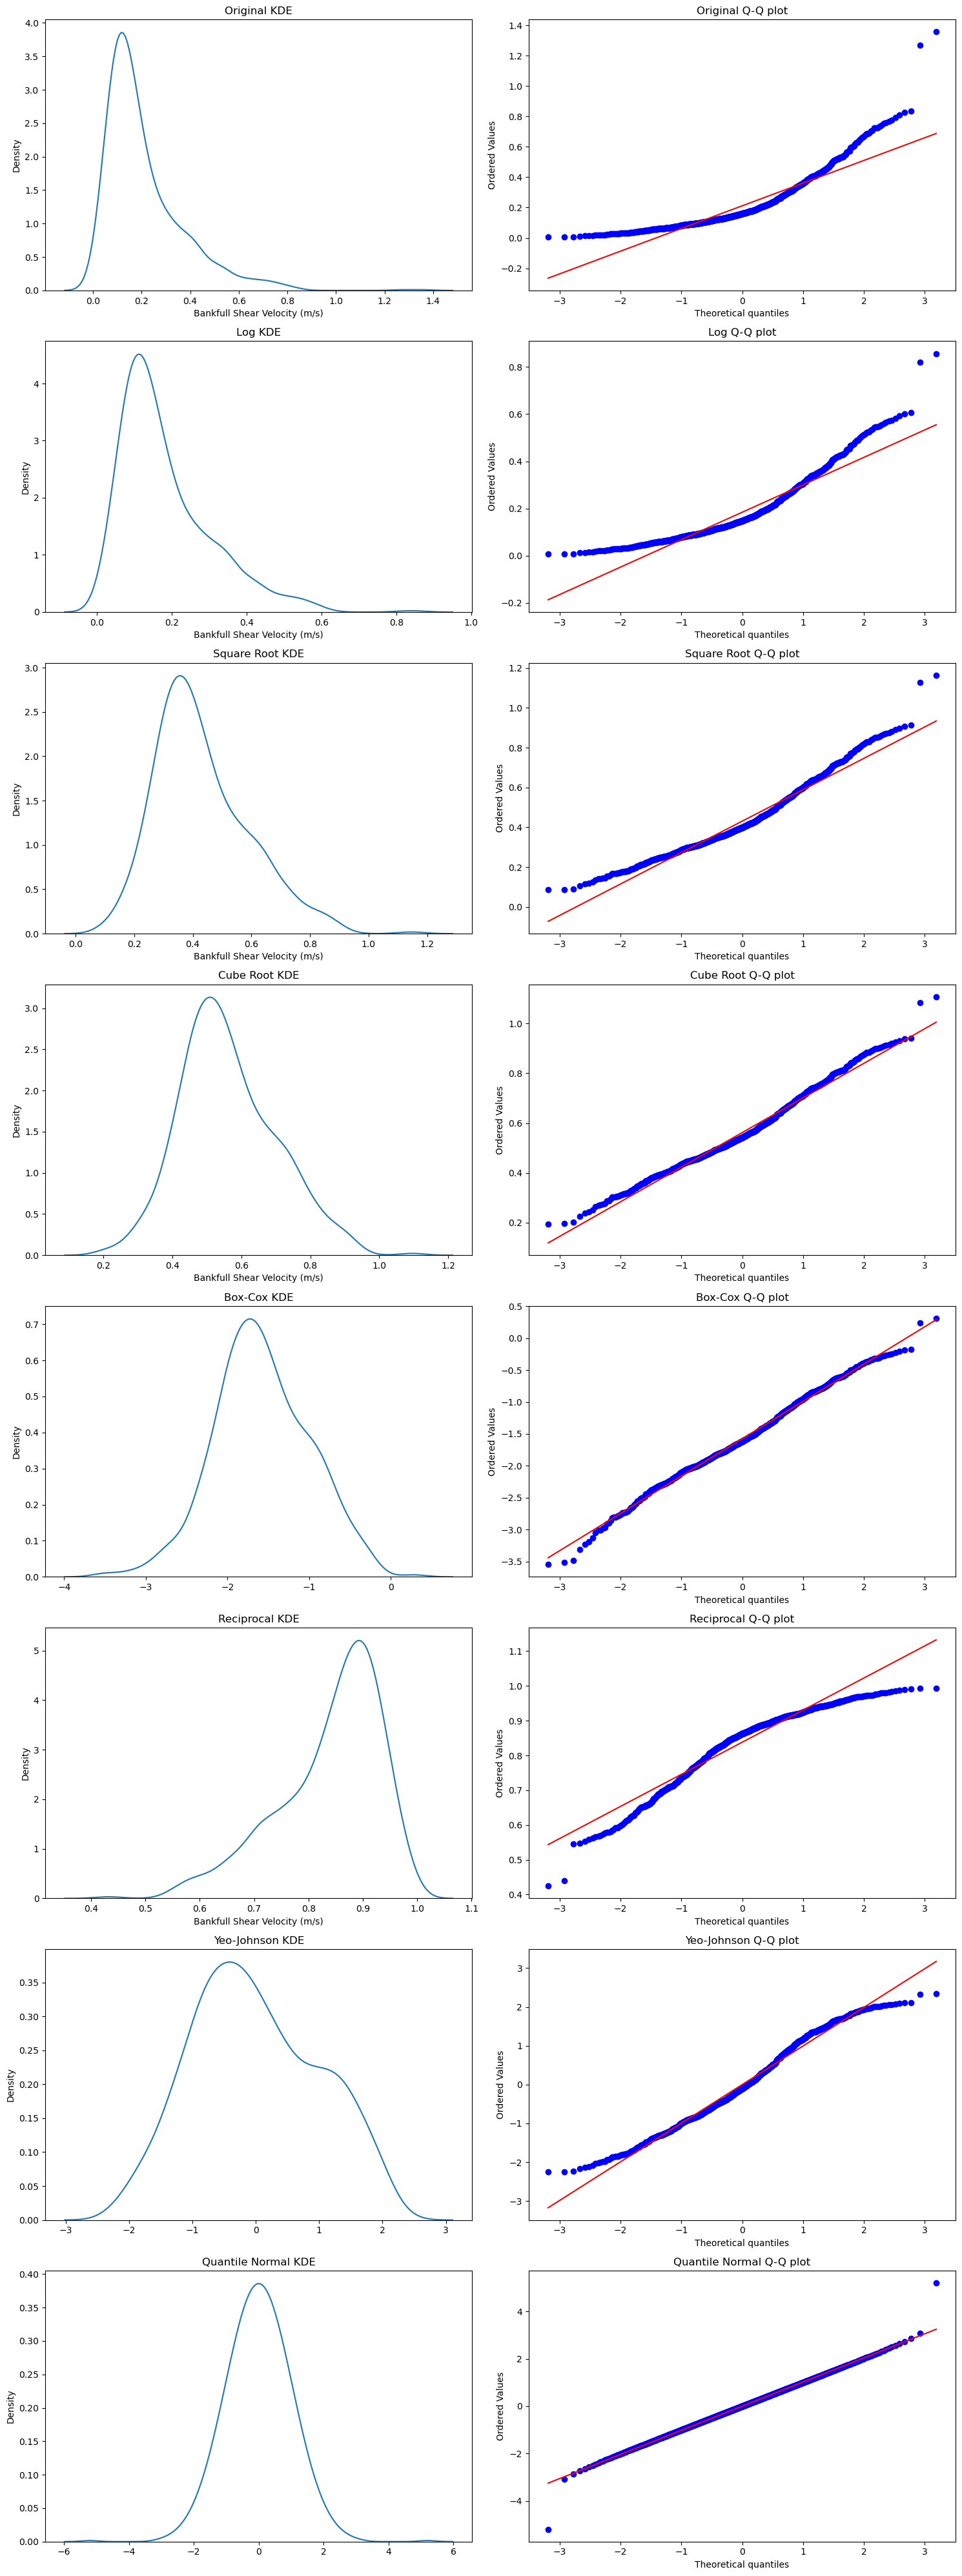

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.8381, p-value = 0.0000
  Anderson-Darling Test Statistic = 42.0896, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.8923, p-value = 0.0000
  Anderson-Darling Test Statistic = 29.8925, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9608, p-value = 0.0000
  Anderson-Darling Test Statistic = 11.4771, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9848, p-value = 0.0000
  Anderson-Darling Test Statistic = 5.3283, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9955, p-value = 0.0066
  Anderson-Darling Test Statistic = 1.5270, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.9306, p-value = 0.0000
  Anderson-Darling Test Statistic = 20.4

In [24]:
# Normality plot for u*
normality(epa_1819, 'Bankfull Shear Velocity (m/s)')

#### Mean high values of soil bulk density

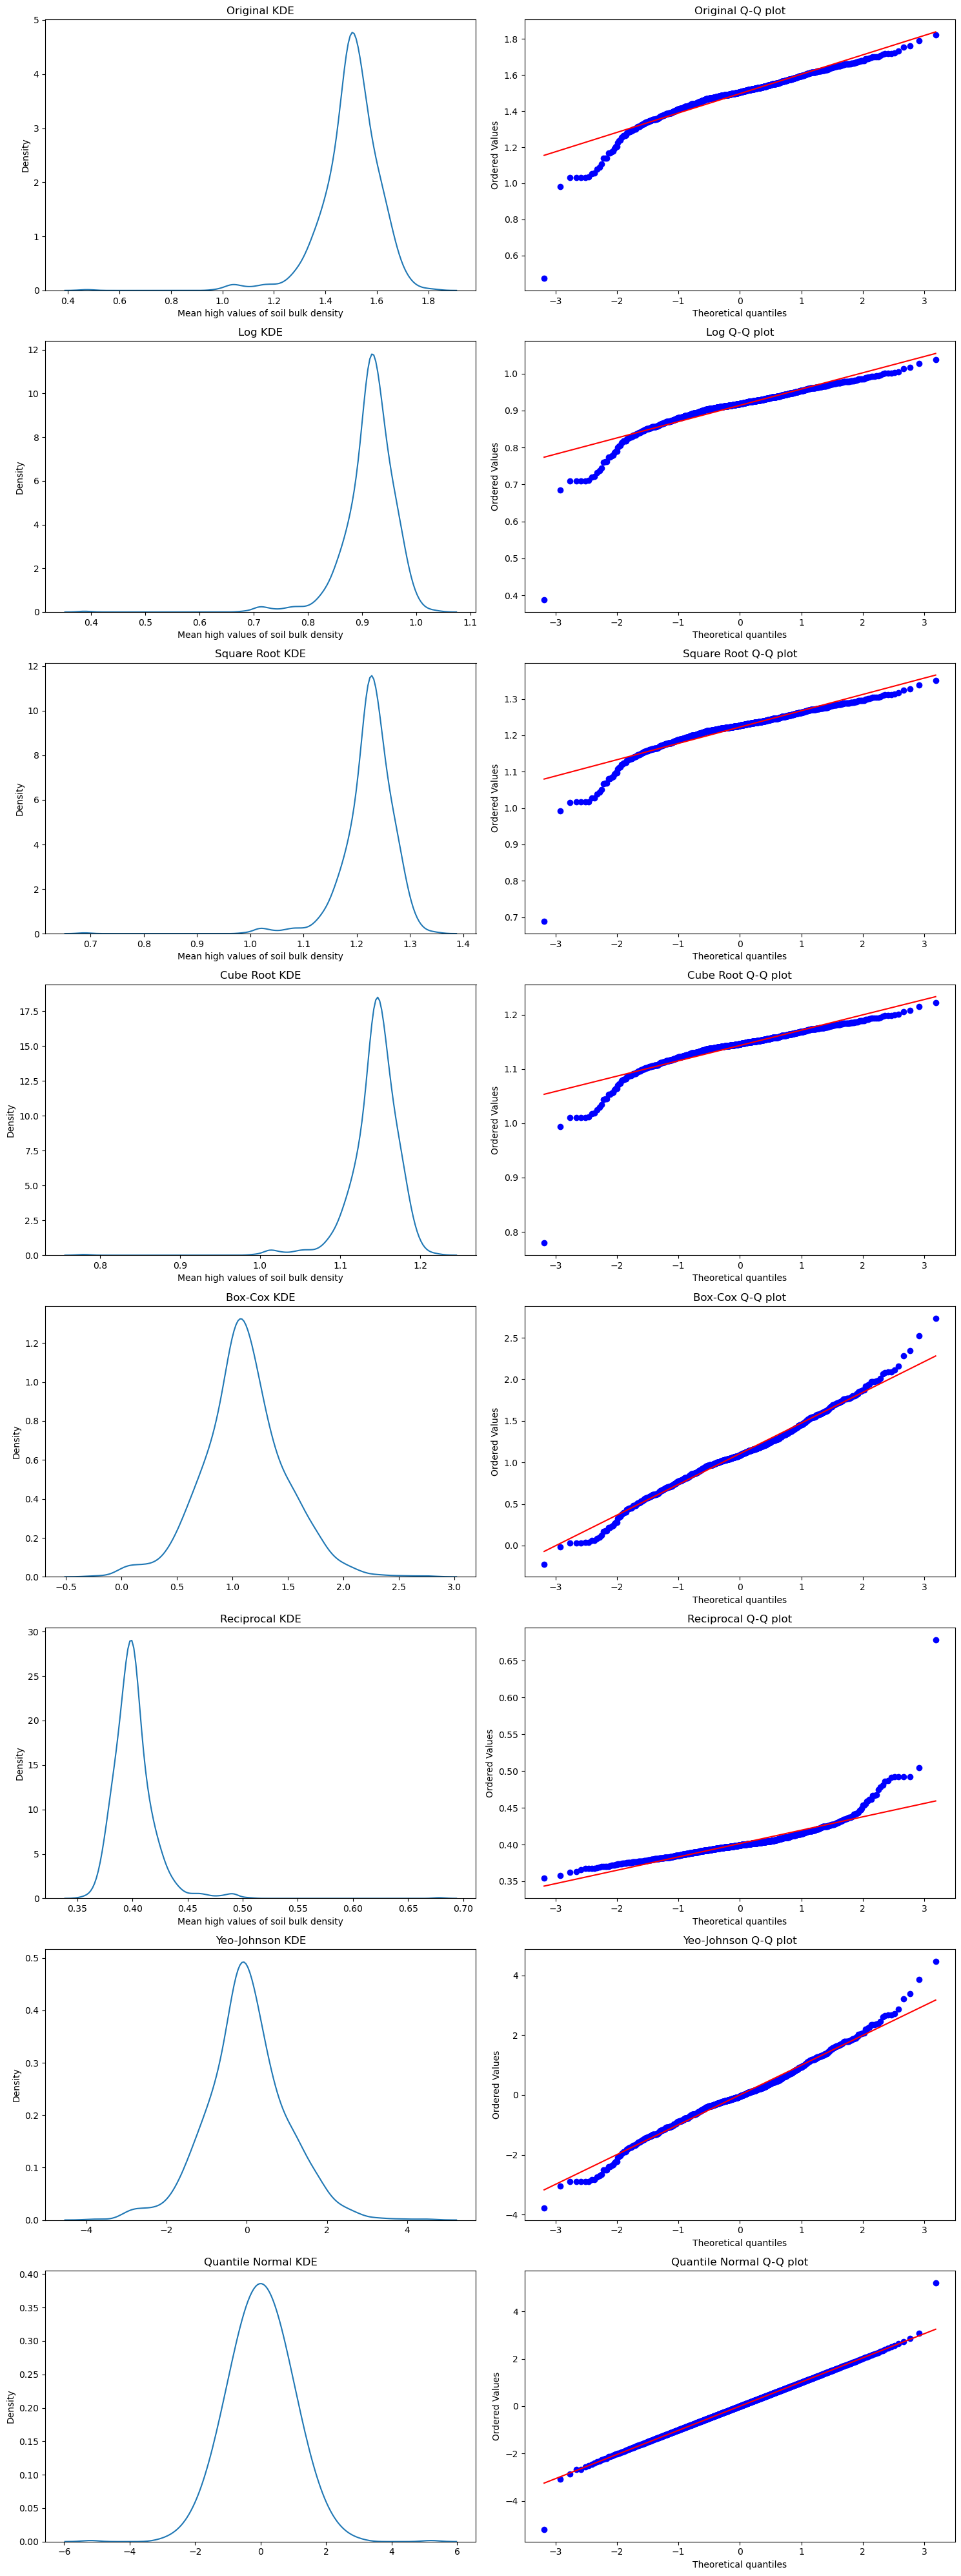

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.9067, p-value = 0.0000
  Anderson-Darling Test Statistic = 13.6113, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.8595, p-value = 0.0000
  Anderson-Darling Test Statistic = 19.3322, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.8627, p-value = 0.0000
  Anderson-Darling Test Statistic = 18.7130, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.8438, p-value = 0.0000
  Anderson-Darling Test Statistic = 20.9047, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9884, p-value = 0.0000
  Anderson-Darling Test Statistic = 3.5504, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.7922, p-value = 0.0000
  Anderson-Darling Test Statistic = 27.

In [25]:
# Normality plots for soil density
normality(epa_1819, 'Mean high values of soil bulk density')

#### Mean watershed elevation

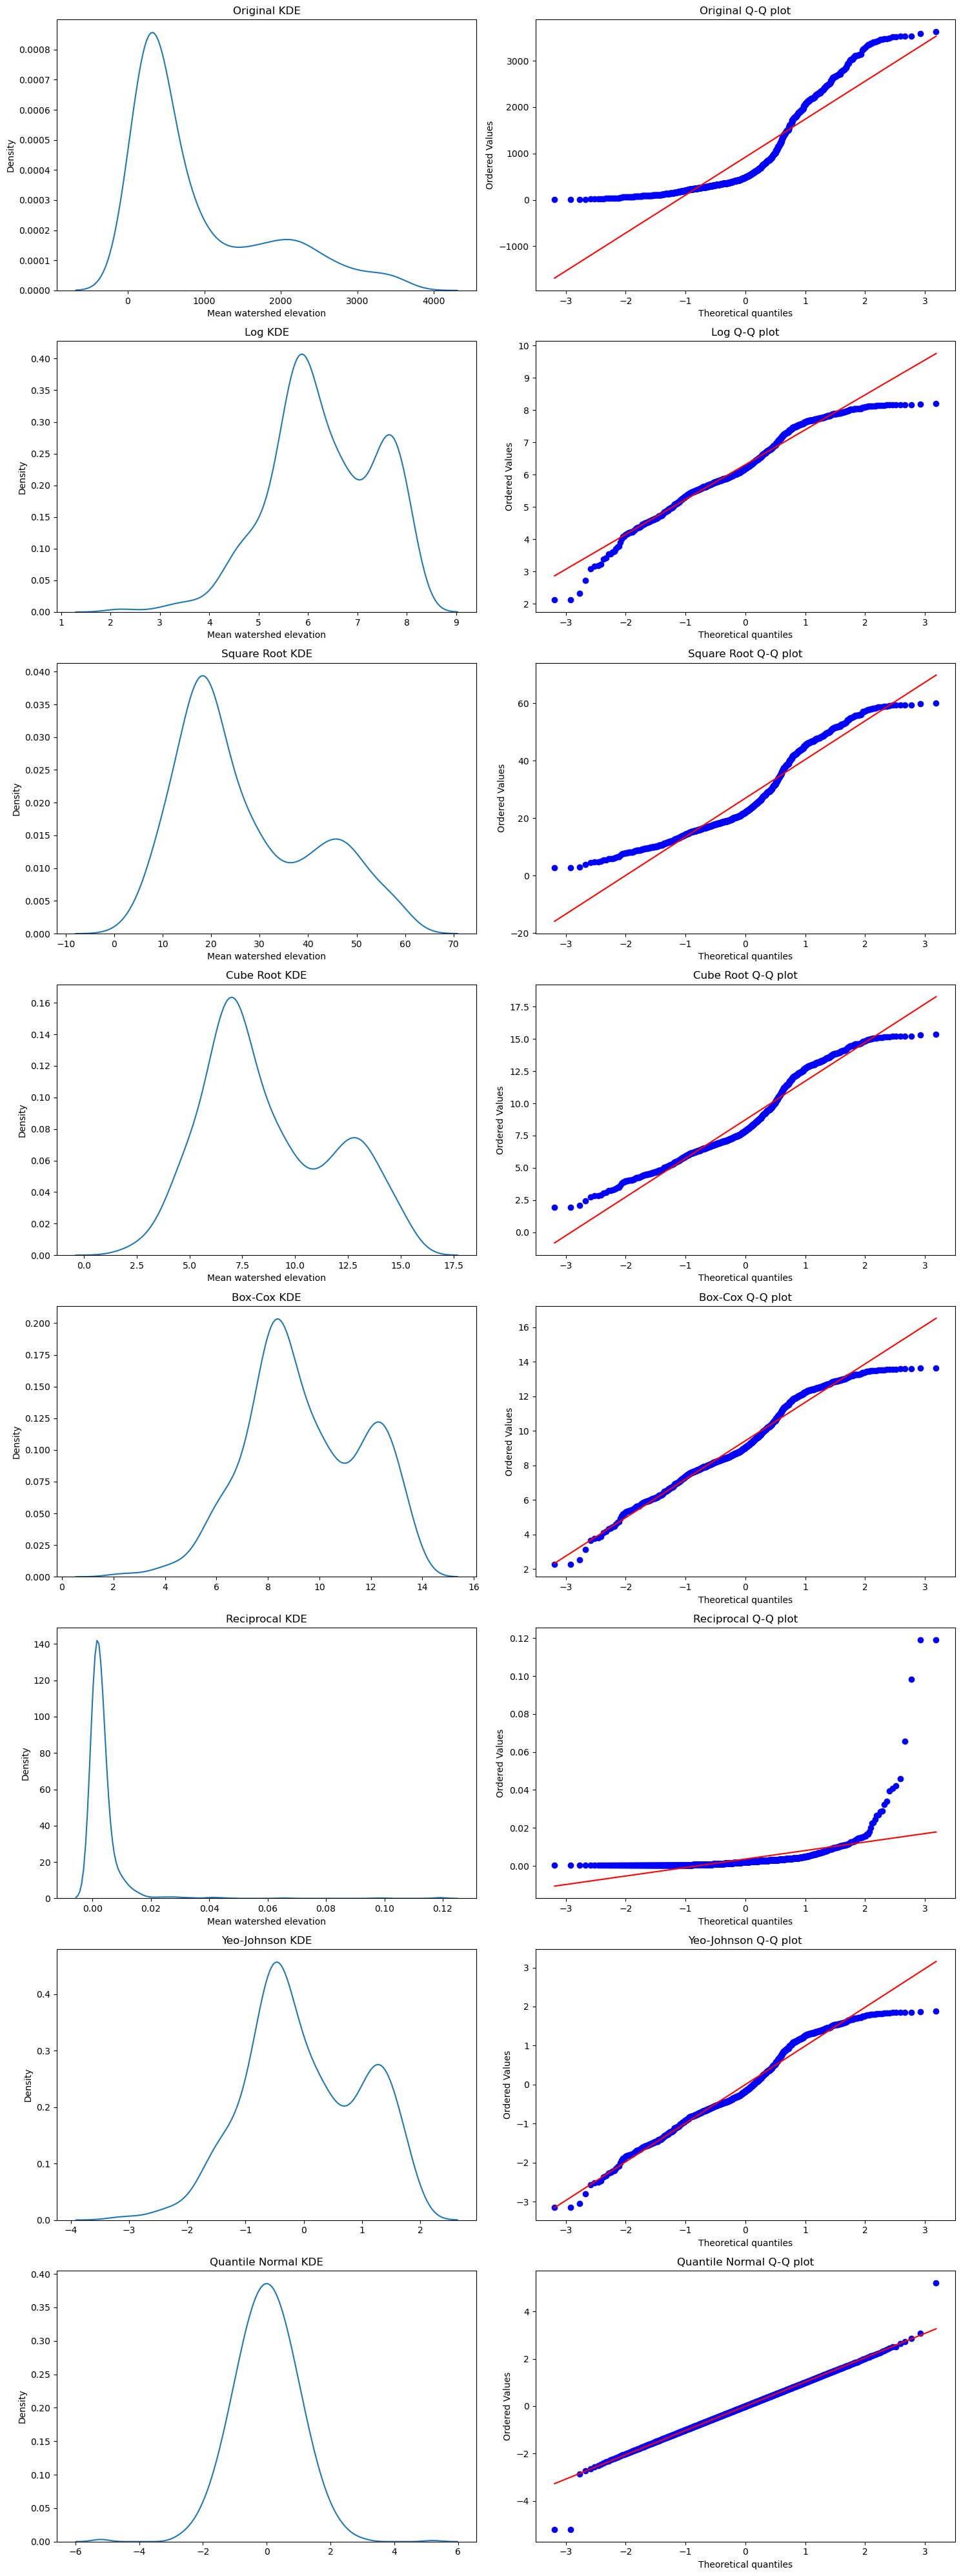

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.8185, p-value = 0.0000
  Anderson-Darling Test Statistic = 67.9929, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9709, p-value = 0.0000
  Anderson-Darling Test Statistic = 6.6391, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9224, p-value = 0.0000
  Anderson-Darling Test Statistic = 29.1409, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9522, p-value = 0.0000
  Anderson-Darling Test Statistic = 18.3233, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9737, p-value = 0.0000
  Anderson-Darling Test Statistic = 8.6874, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.3246, p-value = 0.0000
  Anderson-Darling Test Statistic = 166.

In [26]:
# Normality plots for elevation
normality(epa_1819, 'Mean watershed elevation')

#### Mean of all hydraulic conductivity of surface or near surface geology values within watershed

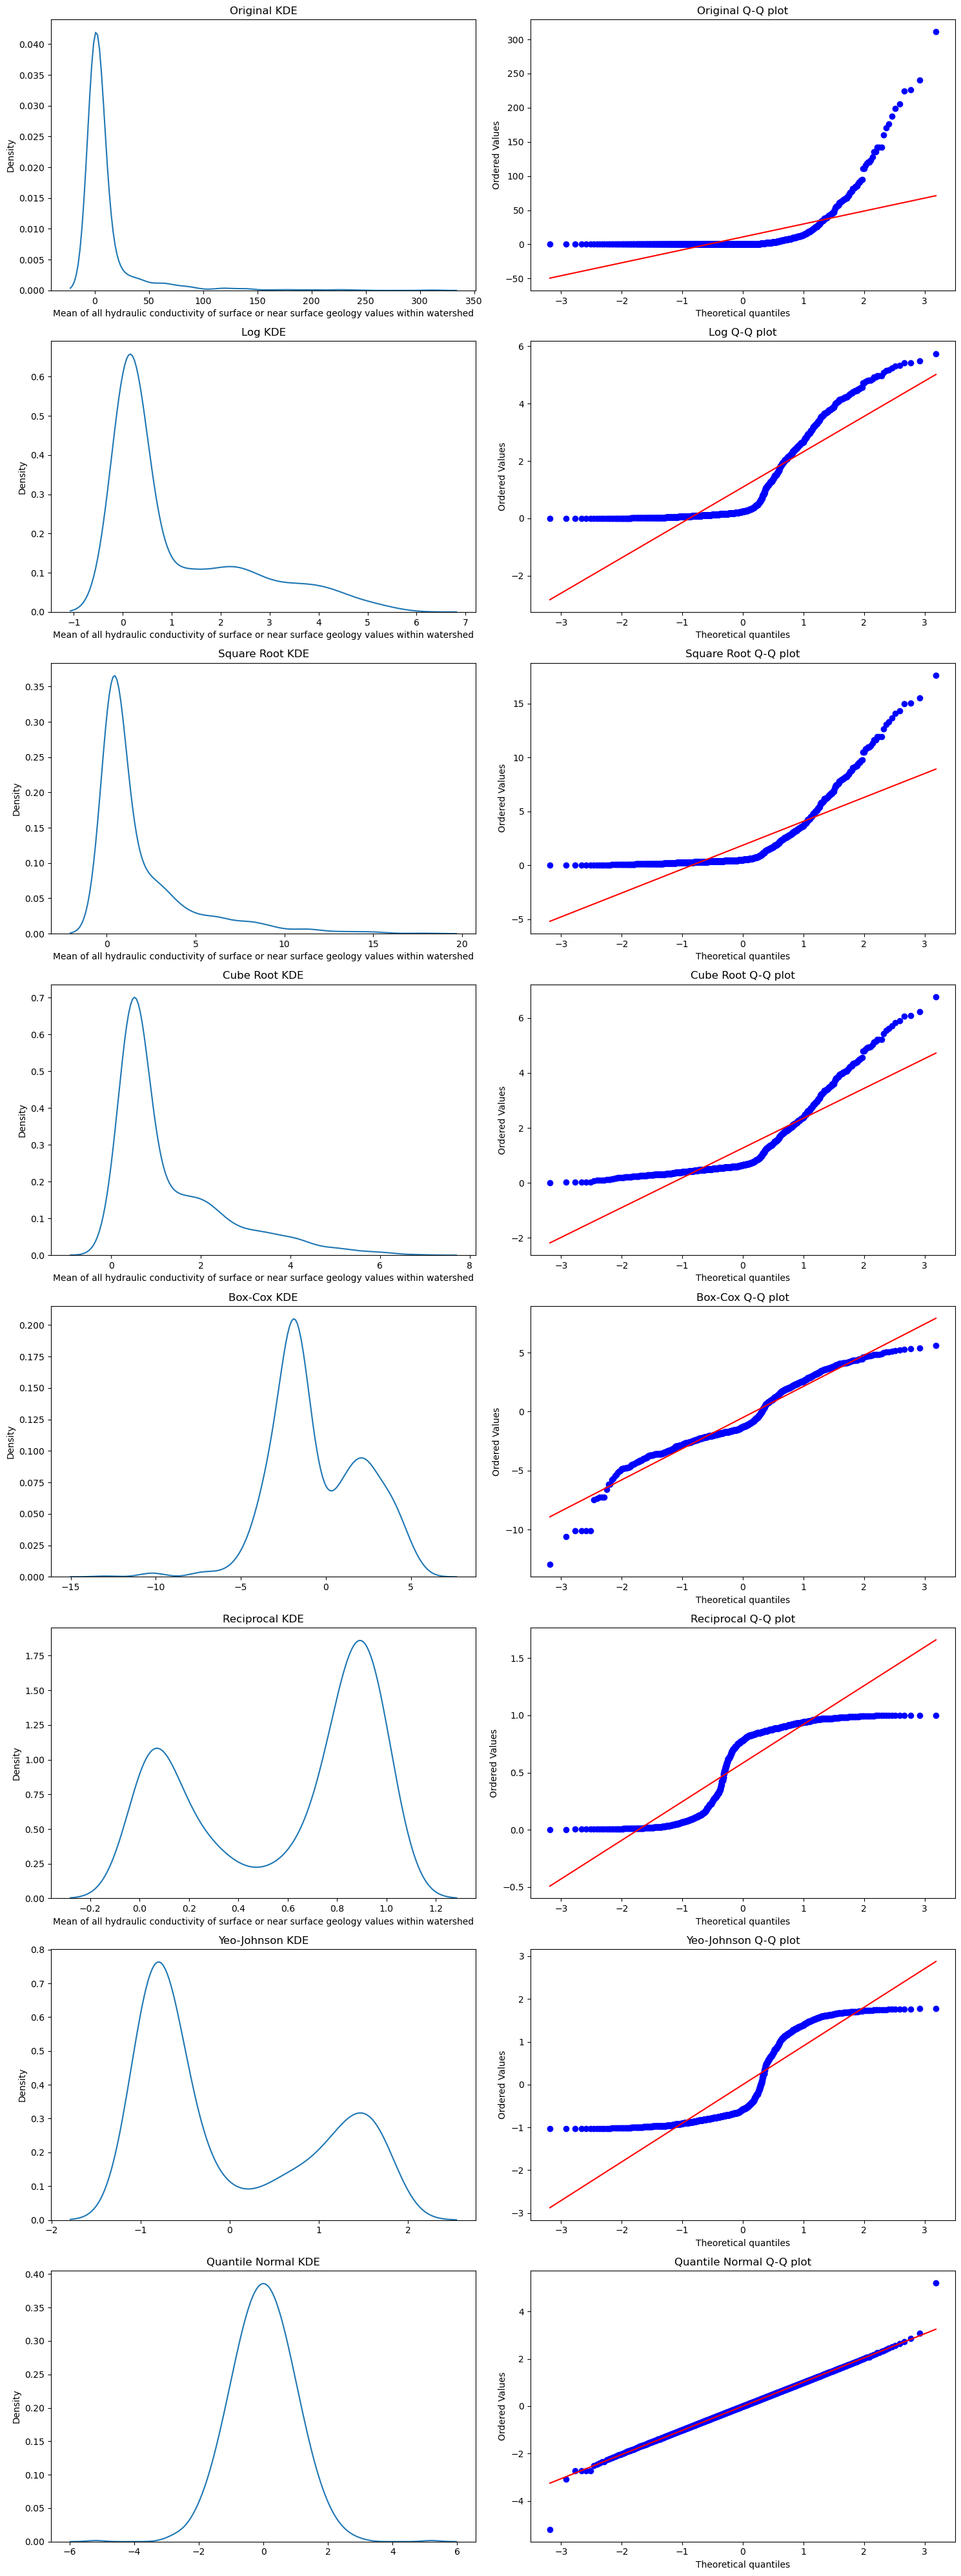

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.4060, p-value = 0.0000
  Anderson-Darling Test Statistic = 206.7855, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.7585, p-value = 0.0000
  Anderson-Darling Test Statistic = 96.1232, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.6675, p-value = 0.0000
  Anderson-Darling Test Statistic = 114.6054, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.7789, p-value = 0.0000
  Anderson-Darling Test Statistic = 78.0720, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9559, p-value = 0.0000
  Anderson-Darling Test Statistic = 16.6725, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.8137, p-value = 0.0000
  Anderson-Darling Test Statistic = 

In [27]:
# Normality plots for hydraulic conductivity
normality(epa_1819, 'Mean of all hydraulic conductivity of surface or near surface geology values within watershed')

#### % of watershed areas classified as evergreen forest land cover

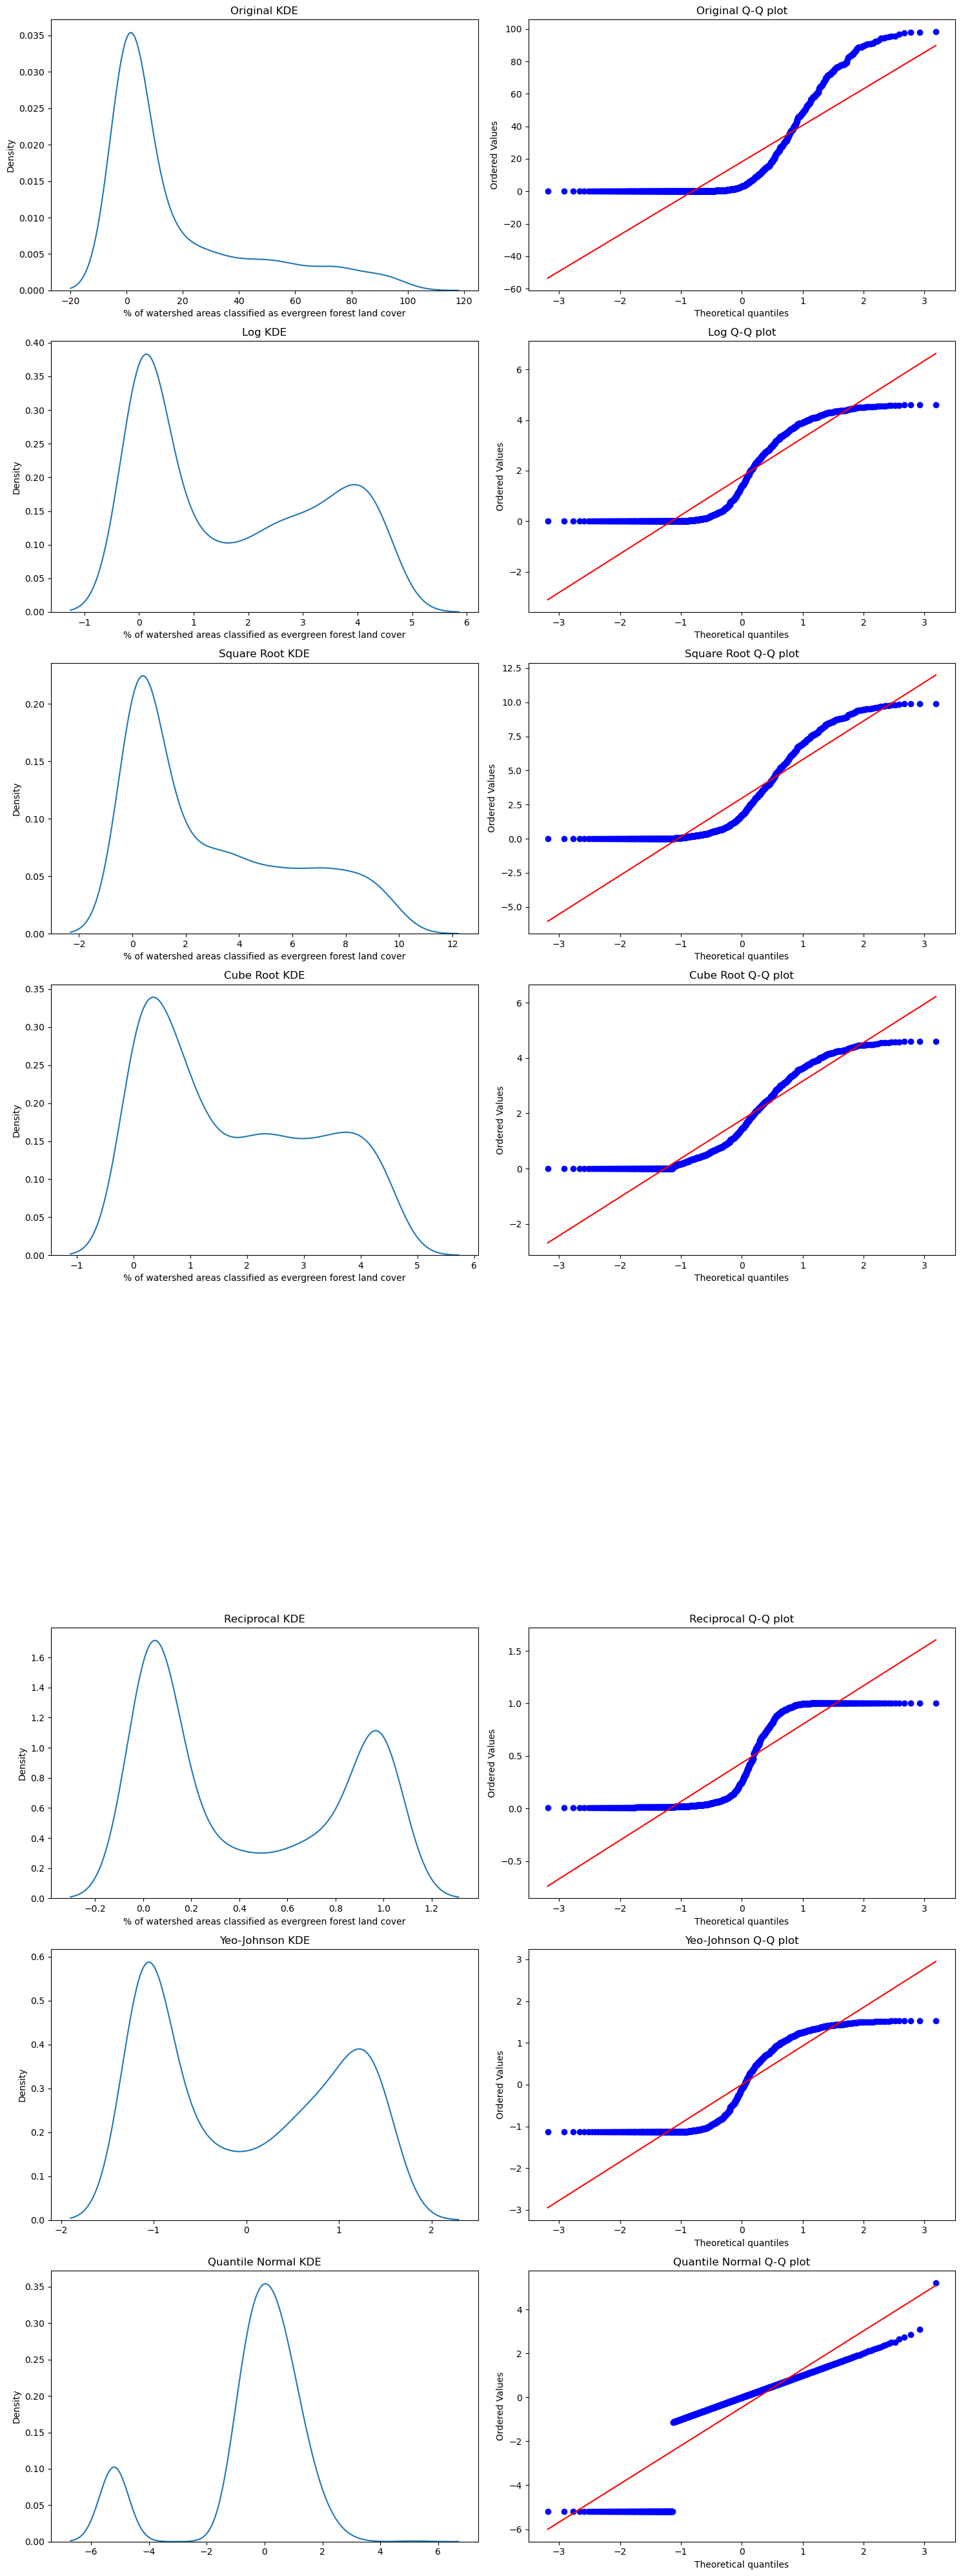

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.7262, p-value = 0.0000
  Anderson-Darling Test Statistic = 107.0341, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.8528, p-value = 0.0000
  Anderson-Darling Test Statistic = 51.4824, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.8526, p-value = 0.0000
  Anderson-Darling Test Statistic = 51.2724, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9059, p-value = 0.0000
  Anderson-Darling Test Statistic = 28.6834, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.7918, p-value = 0.0000
  Anderson-Darling Test Statistic = 79.4281, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.8496, p-value = 0.0000
  Anderson-Darling Test Statistic

In [28]:
# Normality plots for evergreen forest
normality(epa_1819, '% of watershed areas classified as evergreen forest land cover')

#### % crop land

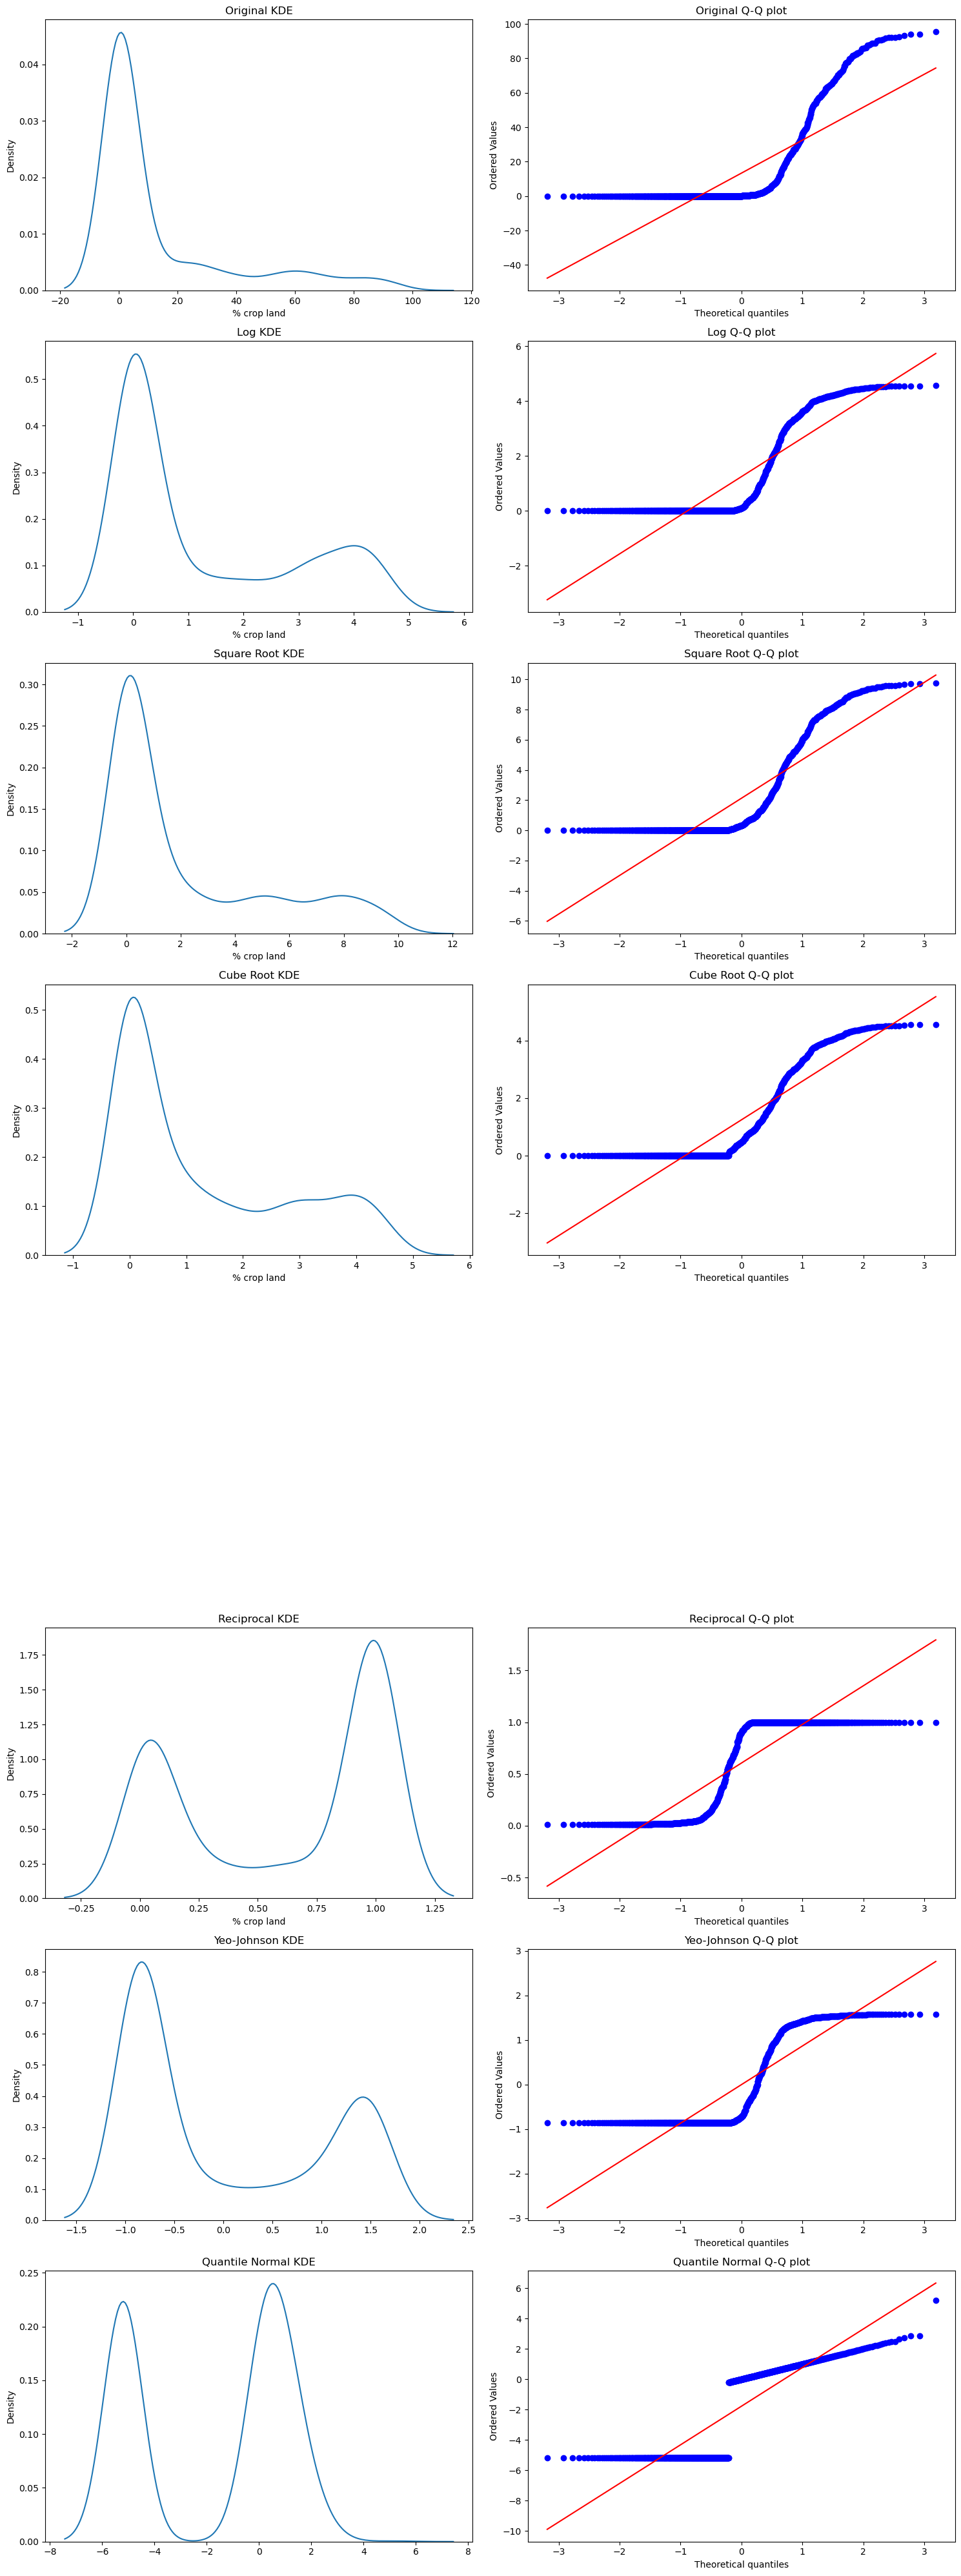

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.6185, p-value = 0.0000
  Anderson-Darling Test Statistic = 161.7278, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.7409, p-value = 0.0000
  Anderson-Darling Test Statistic = 109.1033, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.7338, p-value = 0.0000
  Anderson-Darling Test Statistic = 108.5933, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.7905, p-value = 0.0000
  Anderson-Darling Test Statistic = 80.7662, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.7366, p-value = 0.0000
  Anderson-Darling Test Statistic = 109.7406, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.7467, p-value = 0.0000
  Anderson-Darling Test Statis

In [29]:
# Normality plots for crop land
normality(epa_1819, '% crop land')

#### % deciduous forest

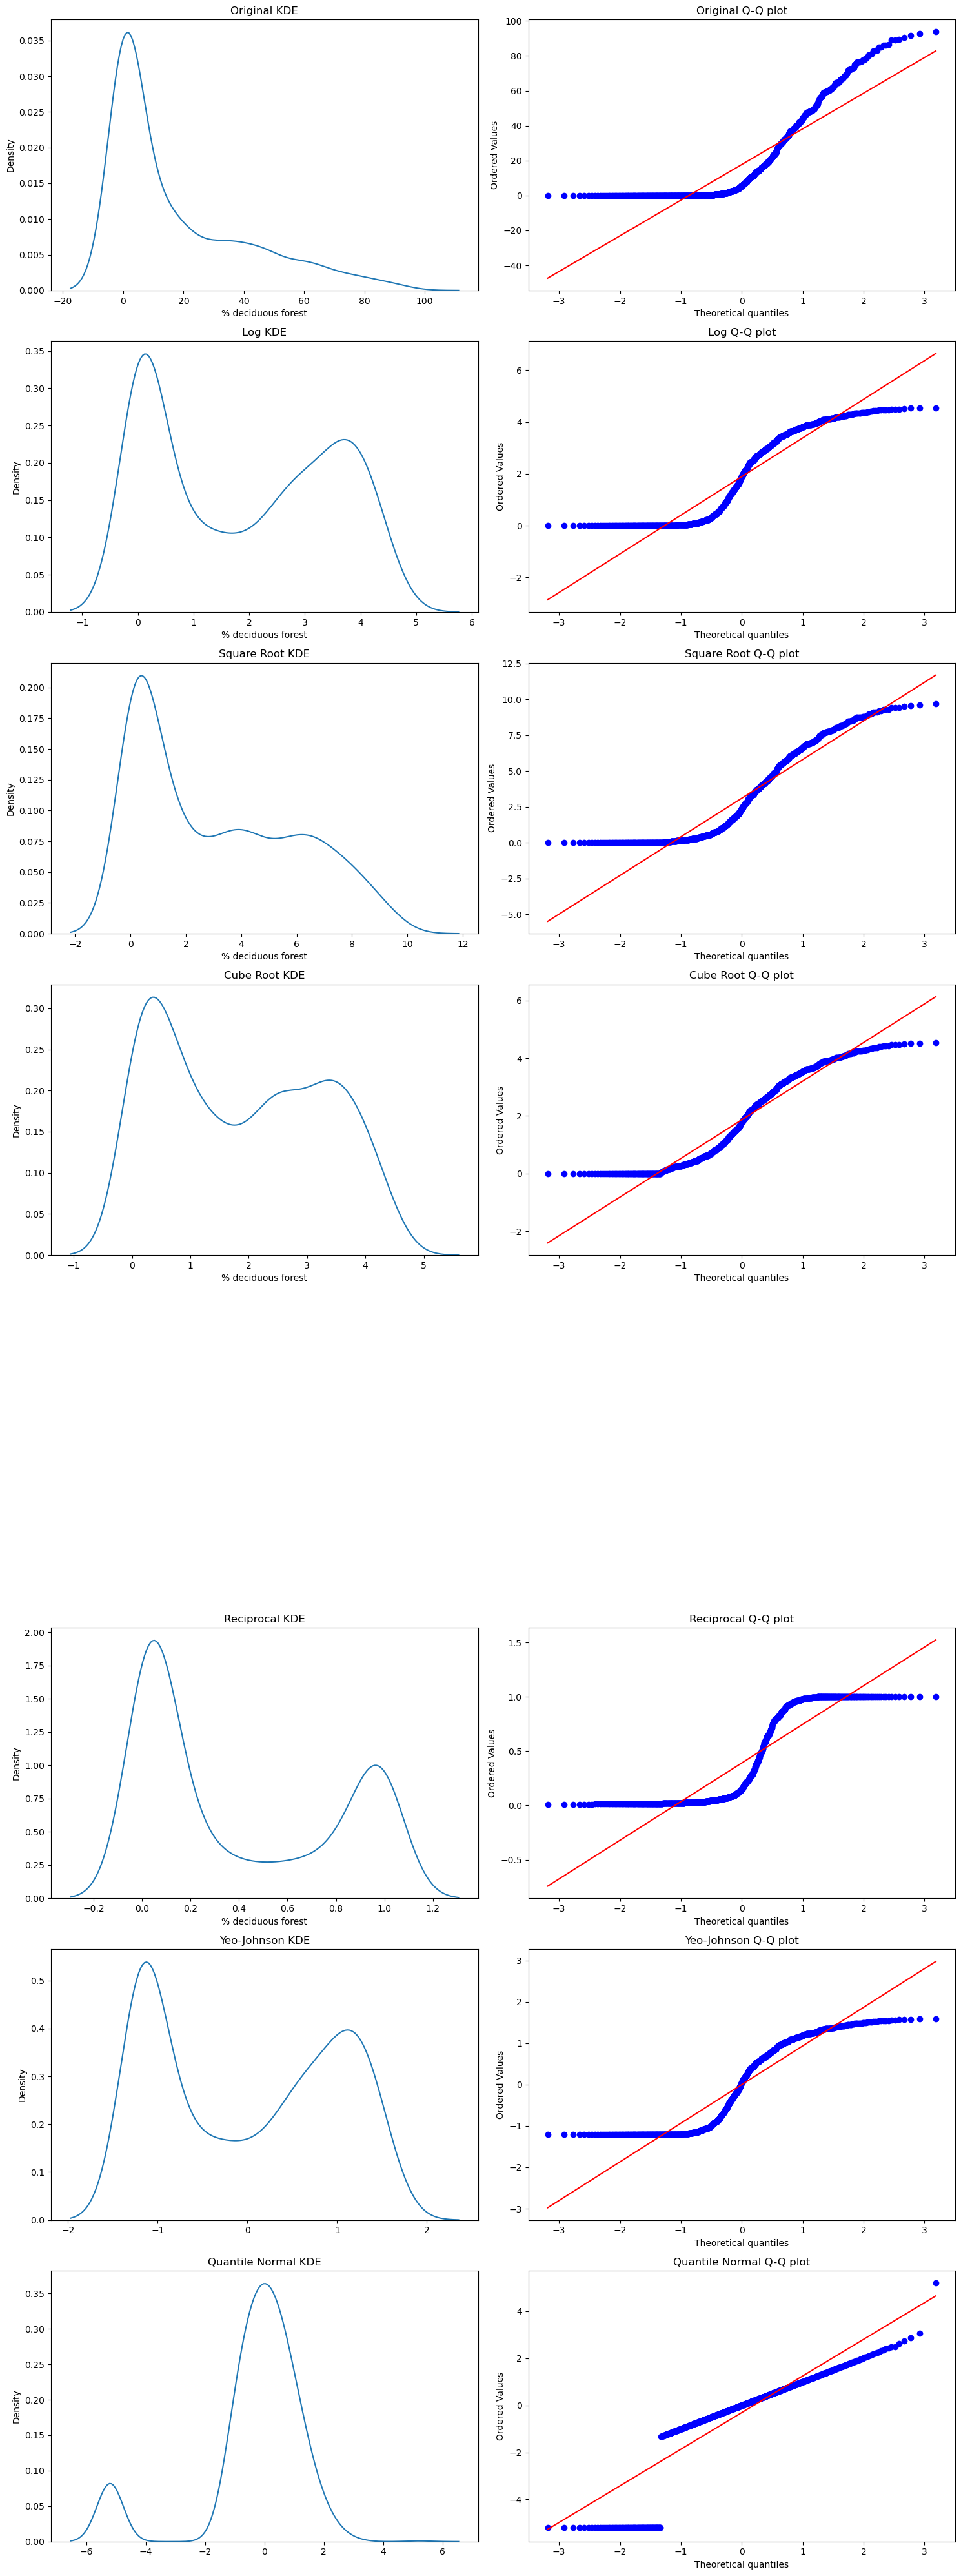

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.7816, p-value = 0.0000
  Anderson-Darling Test Statistic = 79.9647, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.8689, p-value = 0.0000
  Anderson-Darling Test Statistic = 44.7648, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.8885, p-value = 0.0000
  Anderson-Darling Test Statistic = 36.6453, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9232, p-value = 0.0000
  Anderson-Darling Test Statistic = 22.9864, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.7733, p-value = 0.0000
  Anderson-Darling Test Statistic = 89.9018, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.8656, p-value = 0.0000
  Anderson-Darling Test Statistic 

In [30]:
# Normality plots for deciduous forest
normality(epa_1819, '% deciduous forest')

#### % hay

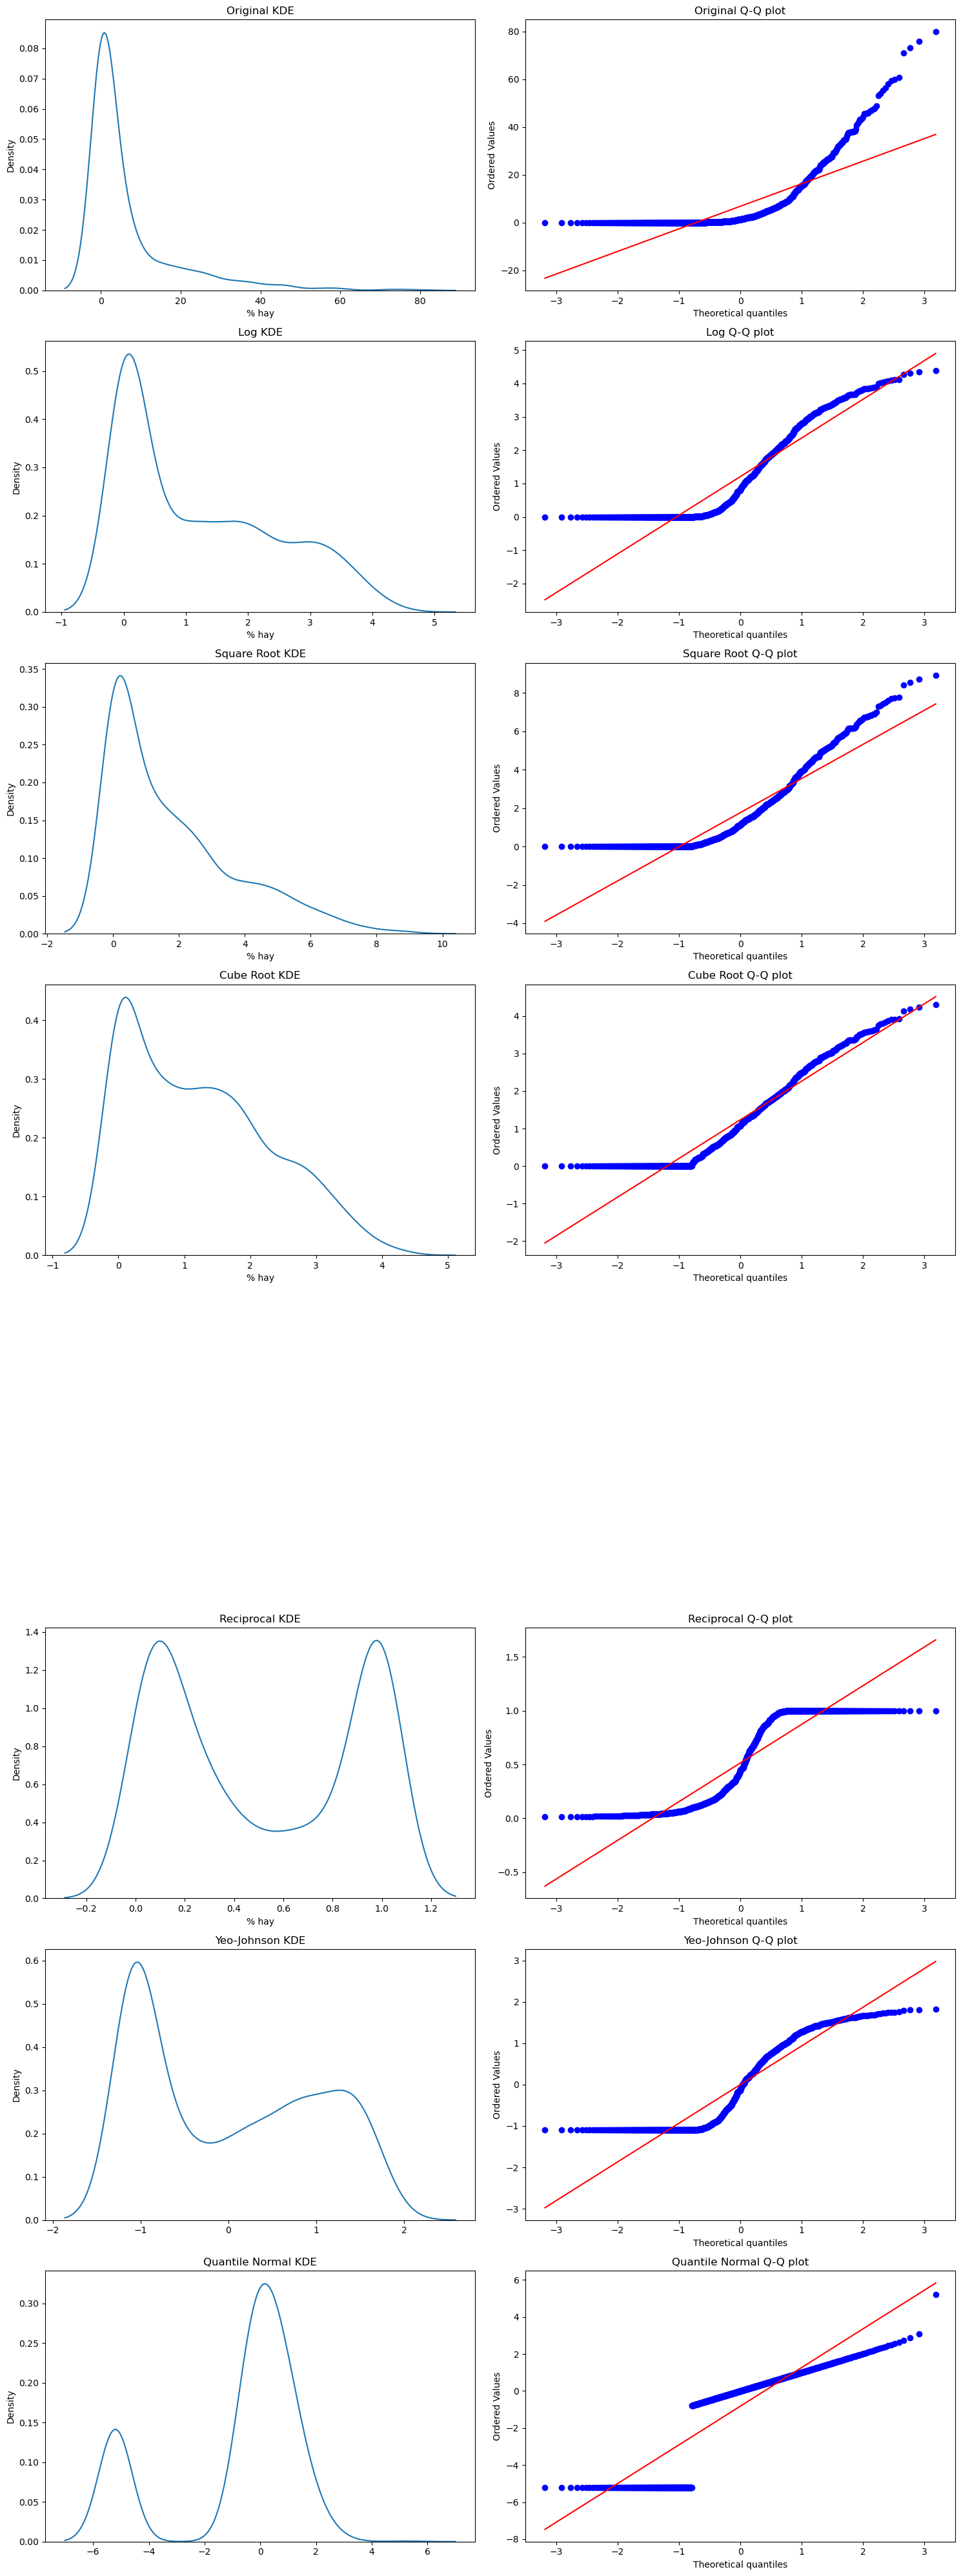

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.6329, p-value = 0.0000
  Anderson-Darling Test Statistic = 126.1420, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.8613, p-value = 0.0000
  Anderson-Darling Test Statistic = 47.4319, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.8504, p-value = 0.0000
  Anderson-Darling Test Statistic = 46.3096, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9208, p-value = 0.0000
  Anderson-Darling Test Statistic = 21.1135, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.8250, p-value = 0.0000
  Anderson-Darling Test Statistic = 63.0884, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.8645, p-value = 0.0000
  Anderson-Darling Test Statistic

In [31]:
# Normality plots for hay
normality(epa_1819, '% hay')

#### Mean imperviousness of anthropogenic surfaces within watershed

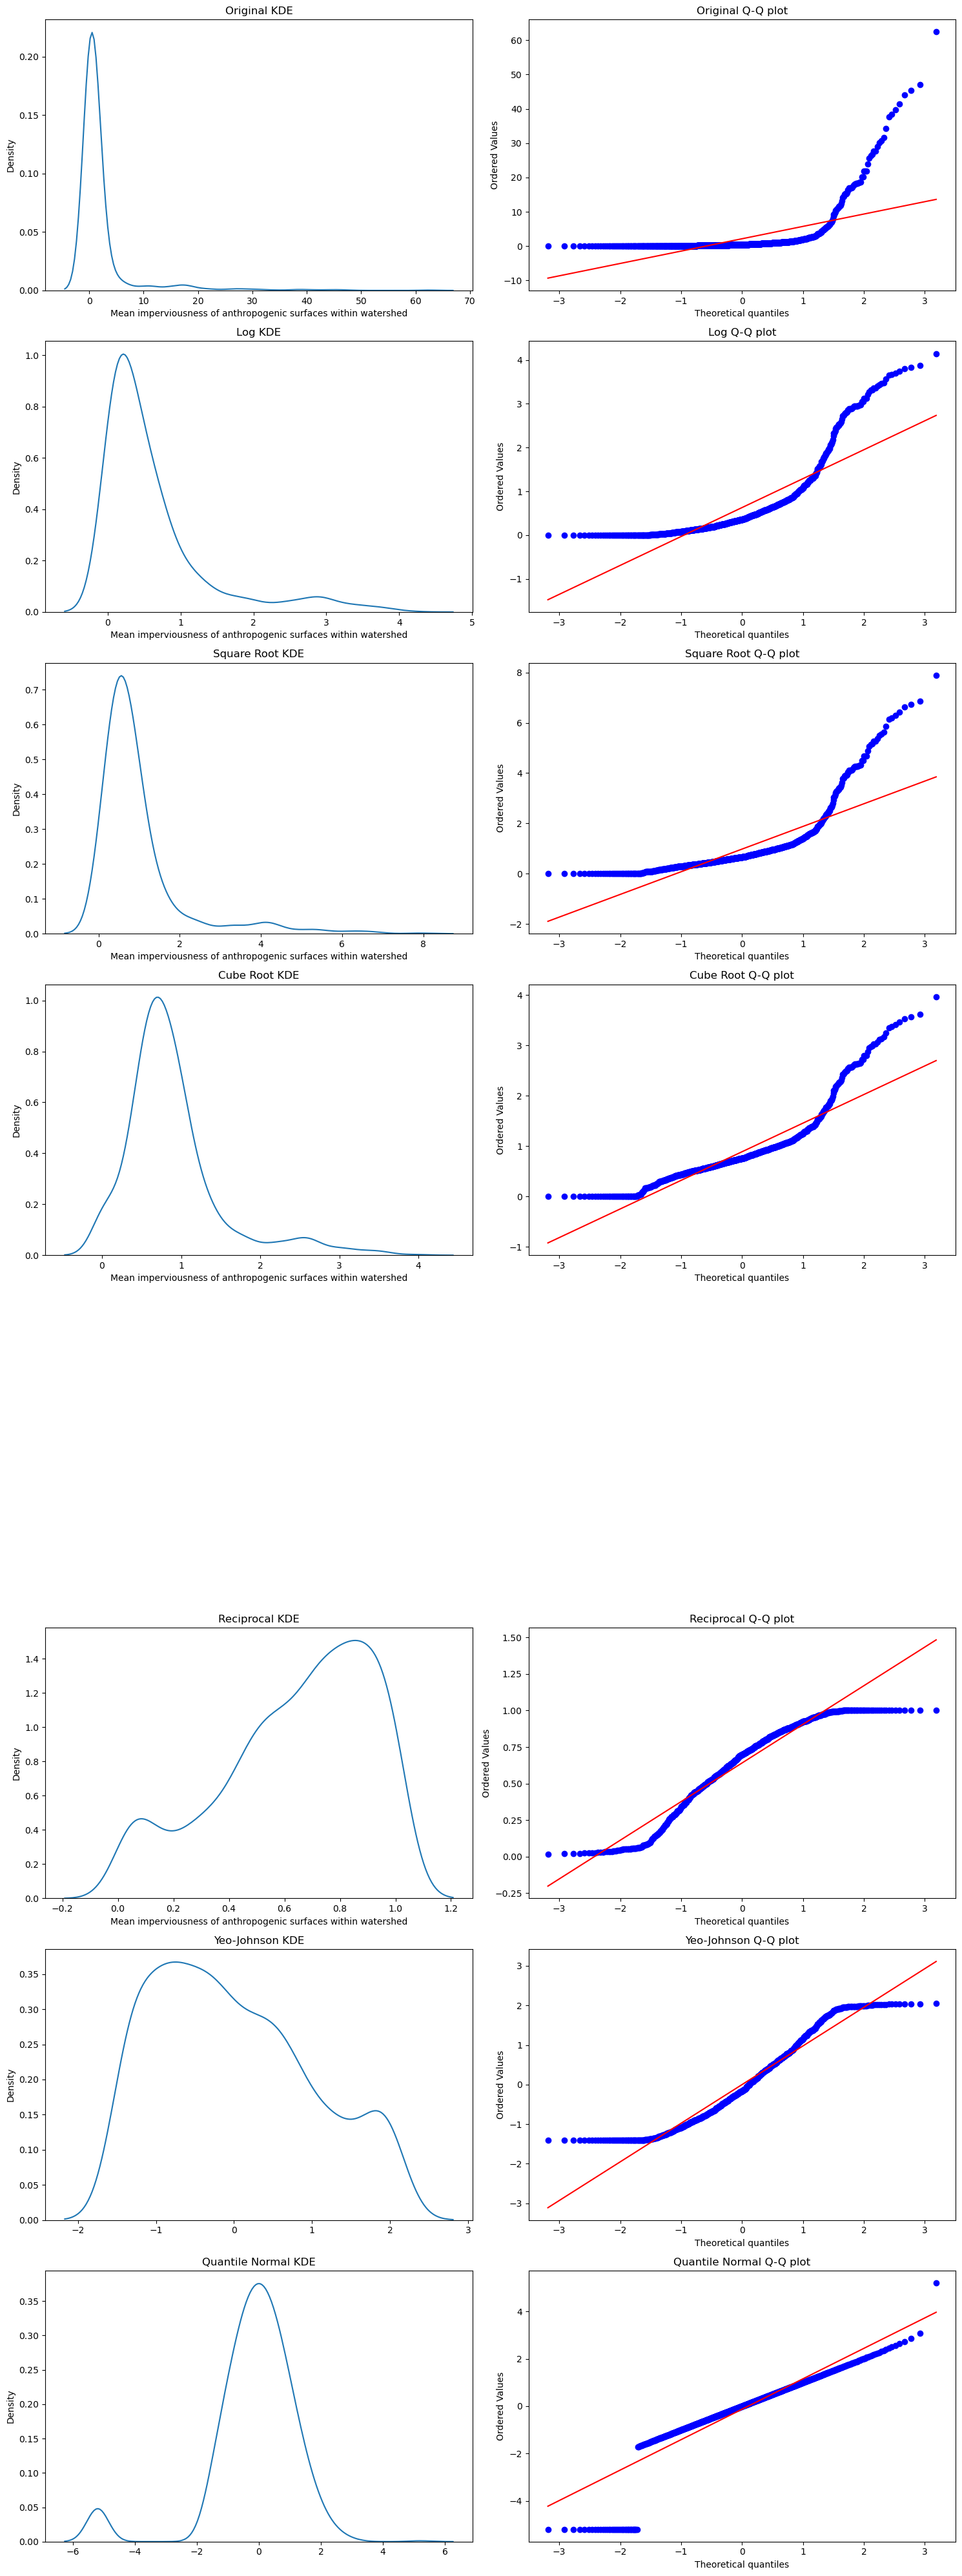

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.3704, p-value = 0.0000
  Anderson-Darling Test Statistic = 223.8186, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.7269, p-value = 0.0000
  Anderson-Darling Test Statistic = 83.8765, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.6752, p-value = 0.0000
  Anderson-Darling Test Statistic = 94.7935, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.8377, p-value = 0.0000
  Anderson-Darling Test Statistic = 43.8310, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.9323, p-value = 0.0000
  Anderson-Darling Test Statistic = 16.7563, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.9459, p-value = 0.0000
  Anderson-Darling Test Statistic

In [32]:
# Normality plots for anthropogenic surfaces
normality(epa_1819, 'Mean imperviousness of anthropogenic surfaces within watershed')

#### Estimated watershed annual runoff

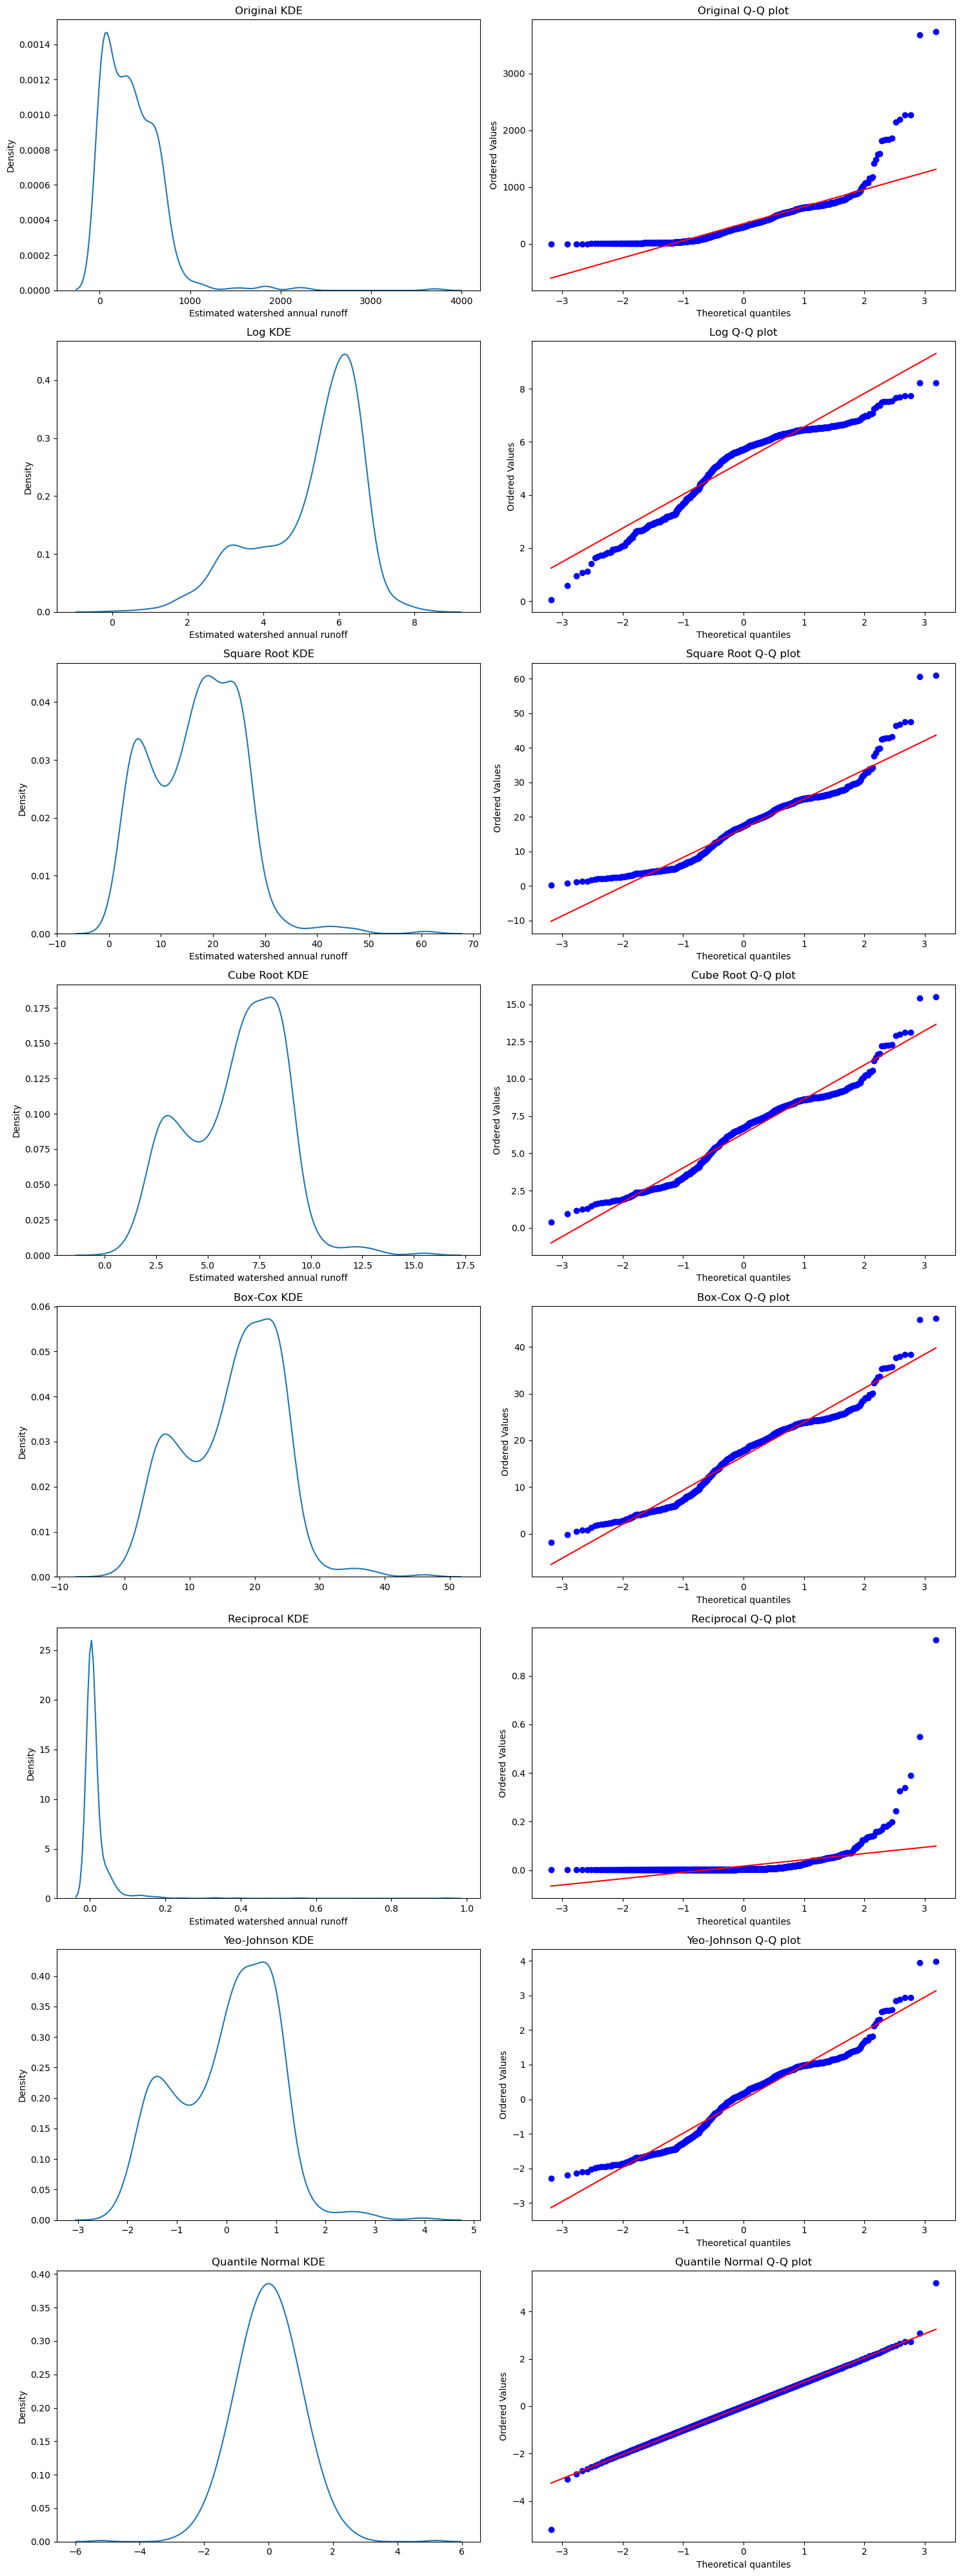

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.7658, p-value = 0.0000
  Anderson-Darling Test Statistic = 26.6871, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9038, p-value = 0.0000
  Anderson-Darling Test Statistic = 36.6755, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9540, p-value = 0.0000
  Anderson-Darling Test Statistic = 8.7588, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9622, p-value = 0.0000
  Anderson-Darling Test Statistic = 13.5432, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9624, p-value = 0.0000
  Anderson-Darling Test Statistic = 13.1227, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.2955, p-value = 0.0000
  Anderson-Darling Test Statistic = 199

In [33]:
# Normality plots for runoff
normality(epa_1819, 'Estimated watershed annual runoff')

#### Mean Composte Topographic Index (CTI)[Wetness Index]

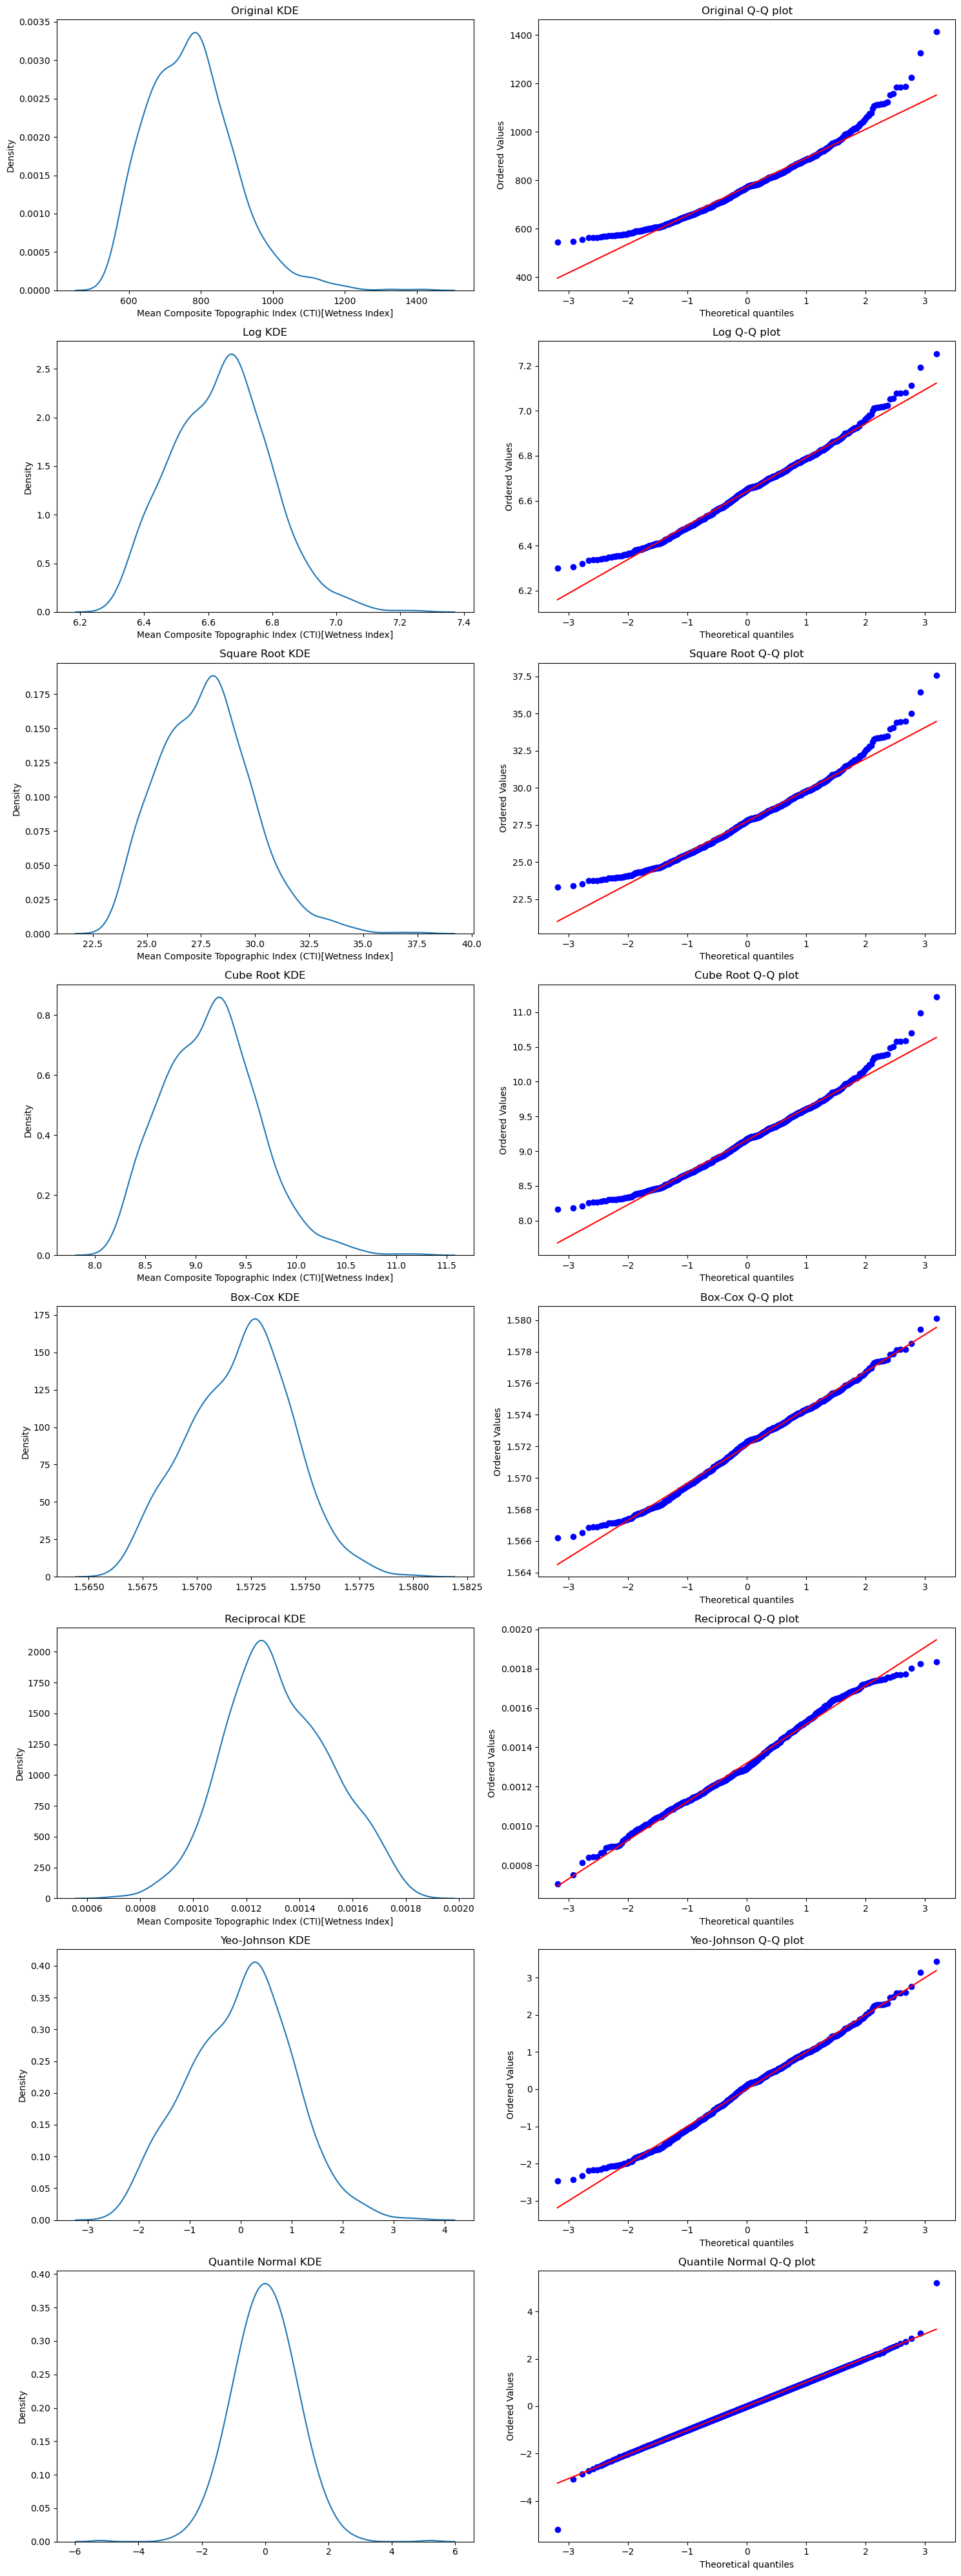

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.9659, p-value = 0.0000
  Anderson-Darling Test Statistic = 4.1379, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9908, p-value = 0.0000
  Anderson-Darling Test Statistic = 1.1160, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9815, p-value = 0.0000
  Anderson-Darling Test Statistic = 2.0311, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9853, p-value = 0.0000
  Anderson-Darling Test Statistic = 1.5987, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9943, p-value = 0.0011
  Anderson-Darling Test Statistic = 1.4961, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.9926, p-value = 0.0001
  Anderson-Darling Test Statistic = 2.4627,

In [34]:
# Normality plot of wetness index
normality(epa_1819, 'Mean Composite Topographic Index (CTI)[Wetness Index]')

In [36]:
epa_1819.columns

Index(['Site ID', 'Unique ID', 'LAT_DD83', 'LON_DD83', 'Collection Date',
       'Mean streambed embeddedness (%)', 'Bankfull Shear Velocity (m/s)',
       'Mean high values of soil bulk density', 'Mean watershed elevation',
       '% of watershed areas classified as evergreen forest land cover',
       'Mean of all hydraulic conductivity of surface or near surface geology values within watershed',
       '% crop land', '% deciduous forest', '% hay',
       'Mean imperviousness of anthropogenic surfaces within watershed',
       'Horton overland flow', 'Estimated watershed annual runoff',
       'Mean Composite Topographic Index (CTI)[Wetness Index]', 'DIVISION'],
      dtype='object')

### Step 3b. Transform features given results

In [37]:
# Define transformers
pt = PowerTransformer(method = 'yeo-johnson')
qt = QuantileTransformer(output_distribution = 'normal')

In [38]:
# Transform features based on visual and statistical results
epa_1819['Bankfull Shear Velocity (m/s) (QT)'] = qt.fit_transform(epa_1819['Bankfull Shear Velocity (m/s)'].values.reshape(-1, 1))
epa_1819['Mean High Values of Soil Bulk Density (QT)'] = qt.fit_transform(epa_1819['Mean high values of soil bulk density'].values.reshape(-1, 1))
epa_1819['Mean Watershed Elevation (QT)'] = qt.fit_transform(epa_1819['Mean watershed elevation'].values.reshape(-1, 1))
epa_1819['Mean of Watershed Hydraulic Conductivity (QT)'] = qt.fit_transform(epa_1819['Mean of all hydraulic conductivity of surface or near surface geology values within watershed'].values.reshape(-1, 1))
epa_1819['% Evergreen Forest (CBRT)'] = np.power(epa_1819['% of watershed areas classified as evergreen forest land cover'], 1/3)
epa_1819['% Crop Land (CBRT)'] = np.power(epa_1819['% crop land'], 1/3)
epa_1819['% Deciduous Forest (CBRT)'] = np.power(epa_1819['% deciduous forest'], 1/3)
epa_1819['% Hay (CBRT)'] = np.power(epa_1819['% hay'], 1/3)
epa_1819['Mean of Watershed Impervious Surface (YJ)'] = pt.fit_transform(epa_1819['Mean imperviousness of anthropogenic surfaces within watershed'].values.reshape(-1, 1))
epa_1819['Estimated Watershed Annual Runoff (QT)'] = qt.fit_transform(epa_1819['Estimated watershed annual runoff'].values.reshape(-1, 1))
epa_1819['Mean Composite Topographic Index (Wetness Index) (QT)'] = qt.fit_transform(epa_1819['Mean Composite Topographic Index (CTI)[Wetness Index]'].values.reshape(-1, 1))

In [39]:
# Select columns for moving forward given transformations above
epa_1819_trim1 = epa_1819[['Site ID',
                        'Unique ID',
                        'LAT_DD83',
                        'LON_DD83',
                        'Collection Date',
                        'Mean streambed embeddedness (%)',
                        'Bankfull Shear Velocity (m/s) (QT)',
                       'Mean High Values of Soil Bulk Density (QT)',
                       'Mean Watershed Elevation (QT)',
                       'Mean of Watershed Hydraulic Conductivity (QT)',
                       '% Evergreen Forest (CBRT)', 
                         '% Crop Land (CBRT)',
                       '% Deciduous Forest (CBRT)', 
                         '% Hay (CBRT)',
                       'Mean of Watershed Impervious Surface (YJ)',
                         'Estimated Watershed Annual Runoff (QT)',
                       'Mean Composite Topographic Index (Wetness Index) (QT)',
                         'DIVISION']]

# Display shape of dataframe
print("The shape of the model dataset is", epa_1819_trim1.shape)

The shape of the model dataset is (962, 18)


In [40]:
# Rename columns for later plotting purposes
epa_1819_trim1 = epa_1819_trim1.rename(columns = {
    'LAT_DD83':'Latitude',
    'LON_DD83':'Longitude',
    'Mean streambed embeddedness (%)':'Streambed Embeddedness (%)',
     'Mean High Values of Soil Bulk Density (QT)':'Soil Bulk Density (QT)',
    'Mean Watershed Elevation (QT)':'Avg Watershed Elev (QT)',
     'Mean of Watershed Hydraulic Conductivity (QT)':'Hydraulic Conductivity (QT)',
   'Mean of Watershed Impervious Surface (YJ)':'Impervious Surface (YJ)',
     'Estimated Watershed Annual Runoff (QT)':'Annual Runoff (QT)',
   'Mean Composite Topographic Index (Wetness Index) (QT)':'CTI (QT)',
     'DIVISION':'Division'})

In [41]:
# Display dataframe
epa_1819_trim1

,Site ID,Unique ID,Latitude,Longitude,Collection Date,Streambed Embeddedness (%),Bankfull Shear Velocity (m/s) (QT),Soil Bulk Density (QT),Avg Watershed Elev (QT),Hydraulic Conductivity (QT),% Evergreen Forest (CBRT),% Crop Land (CBRT),% Deciduous Forest (CBRT),% Hay (CBRT),Impervious Surface (YJ),Annual Runoff (QT),CTI (QT),Division
230,NRS18_AR_10190,2012859,34.280395,-94.448356,2018-07-11,28.818182,0.251731,1.219420,-0.347244,-0.460495,3.634969,0.000000,2.535628,1.013498,0.347176,0.864894,-0.414566,INTERIOR HIGHLANDS
861,NRS18_MI_10050,2013955,44.183918,-86.171185,2019-07-01,61.250000,-0.580000,0.963957,-0.662260,2.562044,2.241070,1.342758,3.473625,0.663787,0.060981,0.394749,1.363463,INTERIOR PLAINS
671,NRS18_NM_10645,2013608,36.597293,-106.063509,2019-04-25,52.545455,1.470157,-0.460495,1.635343,0.483822,3.974337,0.175775,1.856406,0.554710,-0.850664,-0.763158,-0.668770,ROCKY MOUNTAIN SYSTEM
661,NRS18_NE_10011,2013596,40.357431,-98.130438,2018-09-27,92.727273,-0.688473,-0.259817,0.846090,1.363463,2.190570,2.416151,0.839814,1.048109,0.667423,-0.784269,0.592389,INTERIOR PLAINS
696,NRS18_AZ_10843,2013644,34.226934,-111.456414,2019-05-10,48.200000,0.592389,0.111083,0.777193,0.155825,3.922320,0.000000,0.129770,0.139791,0.835865,-0.698425,-0.705098,INTERMONTANE PLATEAUS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,NRS18_MT_11470,2014194,46.791930,-107.837106,2019-07-24,46.909091,-0.583089,0.182285,0.633304,1.015026,2.503097,1.953252,0.331042,1.296623,-0.883857,-0.976485,0.243663,INTERIOR PLAINS
589,NRS18_WY_11151,2013486,44.575647,-109.105182,2018-09-12,64.727273,0.361130,-1.288101,0.887872,0.939343,1.243506,0.000000,0.000000,1.065307,-0.631708,-0.394749,-0.411725,ROCKY MOUNTAIN SYSTEM
505,NRS18_WY_10029,2013358,44.074227,-105.254597,2018-08-27,98.181818,-1.145937,-1.390385,0.708446,0.540329,0.392731,0.682492,0.110008,1.270442,-0.894331,-2.394362,0.475044,INTERIOR PLAINS
1041,NRS18_MT_10009,2014323,46.585589,-111.265709,2019-08-06,17.636364,1.203124,-0.024782,1.203124,-1.863194,4.607699,0.000000,0.000000,0.000000,-1.409289,-0.706771,-0.773670,ROCKY MOUNTAIN SYSTEM


## Step 4. One-hot encoding

In [42]:
# One hot encode 'Physiographic Division'
epa_1819_mdl = pd.get_dummies(epa_1819_trim1,
                              columns = ['Division'],
                              prefix_sep = ': ',
                              drop_first = True)

# Rename again for plotting
epa_1819_mdl = epa_1819_mdl.rename(columns = {'Division: ATLANTIC PLAIN':'Atlantic Plain Division',
                                              'Division: INTERIOR HIGHLANDS':'Interior Highlands Division', 
                                              'Division: INTERIOR PLAINS':'Interior Plains Division',
                                               'Division: INTERMONTANE PLATEAUS':'Intermontane Plateaus Division', 
                                              'Division: LAURENTIAN UPLAND':'Laurentian Upland Division',
                                               'Division: PACIFIC MOUNTAIN SYSTEM':'Pacific Mountain Division', 
                                              'Division: ROCKY MOUNTAIN SYSTEM':'Rocky Mountain Division'})

# Print dataset
epa_1819_mdl

,Site ID,Unique ID,Latitude,Longitude,Collection Date,Streambed Embeddedness (%),Bankfull Shear Velocity (m/s) (QT),Soil Bulk Density (QT),Avg Watershed Elev (QT),Hydraulic Conductivity (QT),...,Impervious Surface (YJ),Annual Runoff (QT),CTI (QT),Atlantic Plain Division,Interior Highlands Division,Interior Plains Division,Intermontane Plateaus Division,Laurentian Upland Division,Pacific Mountain Division,Rocky Mountain Division
230,NRS18_AR_10190,2012859,34.280395,-94.448356,2018-07-11,28.818182,0.251731,1.219420,-0.347244,-0.460495,...,0.347176,0.864894,-0.414566,False,True,False,False,False,False,False
861,NRS18_MI_10050,2013955,44.183918,-86.171185,2019-07-01,61.250000,-0.580000,0.963957,-0.662260,2.562044,...,0.060981,0.394749,1.363463,False,False,True,False,False,False,False
671,NRS18_NM_10645,2013608,36.597293,-106.063509,2019-04-25,52.545455,1.470157,-0.460495,1.635343,0.483822,...,-0.850664,-0.763158,-0.668770,False,False,False,False,False,False,True
661,NRS18_NE_10011,2013596,40.357431,-98.130438,2018-09-27,92.727273,-0.688473,-0.259817,0.846090,1.363463,...,0.667423,-0.784269,0.592389,False,False,True,False,False,False,False
696,NRS18_AZ_10843,2013644,34.226934,-111.456414,2019-05-10,48.200000,0.592389,0.111083,0.777193,0.155825,...,0.835865,-0.698425,-0.705098,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,NRS18_MT_11470,2014194,46.791930,-107.837106,2019-07-24,46.909091,-0.583089,0.182285,0.633304,1.015026,...,-0.883857,-0.976485,0.243663,False,False,True,False,False,False,False
589,NRS18_WY_11151,2013486,44.575647,-109.105182,2018-09-12,64.727273,0.361130,-1.288101,0.887872,0.939343,...,-0.631708,-0.394749,-0.411725,False,False,False,False,False,False,True
505,NRS18_WY_10029,2013358,44.074227,-105.254597,2018-08-27,98.181818,-1.145937,-1.390385,0.708446,0.540329,...,-0.894331,-2.394362,0.475044,False,False,True,False,False,False,False
1041,NRS18_MT_10009,2014323,46.585589,-111.265709,2019-08-06,17.636364,1.203124,-0.024782,1.203124,-1.863194,...,-1.409289,-0.706771,-0.773670,False,False,False,False,False,False,True


## Step 6. Export to Excel for Model Building

In [45]:
# Export to model folder
mdl_path = os.path.join(BASE_DIR, "data", "model_ready", "usepa_1819_mdl.xlsx")
epa_1819_mdl.to_excel(mdl_path)
print(f"Dataset saved to {mdl_path}")

Dataset saved to C:\Users\reill\Documents\VirginiaTech\CzubaResearch\Embeddedness\GitHub\Embeddedness_ML_XAI\data\model_ready\usepa_1819_mdl.xlsx
